# Condensator Ontwerpopdracht

Bij het vak elektromagnetisme zullen jullie in de eerste paar weken diep ingaan op de elektrostatica. Parallel hieraan zullen we bij het vak DEF-D, naast de fysieke ontwerpopdrachten en colleges, deze simulatie-ontwerpopdracht behandelen. Deze simulatie-opdracht is weer nauw verwoven met de tweede fysieke ontwerpopdracht die in week 3.3 gegeven wordt. Je moet het grootste deel van deze simulatie opdracht afronden voordat je aan de fysieke ontwerpopdracht van week 3.3 begint. Het laatste stuk van deze simulatie opdracht maak je na afloop van de fysieke opdracht. De deadline voor het inleveren van deze simulatie-opdracht is in week 3.4

Je werkt bij deze opdracht in teams die wij indelen. Zoek op Brightspace op met wie je samenwerkt en leg via email contact. Maak goede afspraken over hoe je samen gaat werken.

In deze simulatie opdracht beginnen we met een aantal simulaties van verschillende situaties, die jullie daarna zullen interpreteren. Daarna zal wat essentiële voorbereiding op de tweede fysieke ontwerpopdracht besproken worden. En als laatste zal dieper ingegaan worden op hoe jullie metingen van de tweede ontwerpopdracht afwijken van de theorie.

De opdracht bestaat uit de volgende sub-opdrachten die je moet doen voordat je begint aan de fysieke ontwerpopdracht van week 3.3:
1) Een puntlading in de oorsprong.
2) Een uniform geladen schijf bestaande uit puntladingen.
3) Een geladen schijf op een constant potentiaal.
4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$.
5) Voorbereidende opdracht voor de DEF ontwerpopdracht.

Na de fysieke ontwerpopdracht van week 3.3 kan je ten slotte het laatste deel doen:

6) Reflectie opdracht voor na de fysieke ontwerpopdracht.

De opdracht wordt volledig online gedaan, er zullen hiervoor dus ook geen specifieke werkcolleges voor zijn ingeroosterd. Als jullie vragen hebben kunnen jullie die mailen naar het DEF e-mailadres: DEF-TNW@tudelft.nl. Deze opdracht wordt in week 3.4 beoordeeld en herkansingen zijn in week 3.5, zie de studiehandleiding voor details.
   
Technische Instructies:
- Git clone (als nog niet gedaan) het DEF repo en maak een branch voor werken aan deze opdracht. Nodig je groepsgenoot uit als collaborator. Hiervoor staat een manual op brightspace.
- Dit notebook maakt gebruik van een aantal functies die in het bestand ```functions_electrostatics.py``` staan. Dit bestand moet in dezelfde map (folder) staan als dit notebook. Als je git clone doet, gaat dat automatisch goed, maar verplaats dit notebook dus niet naar een andere map, mail het niet naar een mede-student, etc. Als je niet weet wat een map (folder) en een bestand is, bekijk dan [deze tutorial](https://teachbooks.io/files-and-folders/EN/intro.html).

Onderwijs Instructies:
- Beantwoord de vragen die in dit notebook voor komen direct in dit notebook.
- Als je iets moet printen op het scherm als antwoord op een vraag, doe dit op een gestructureerde manier met als dat relevant is de eenheid erbij, zoals je geleerd is bij het Inleidend Practicum.
- Vermijd 'hardcoden' waar mogelijk.
- Bij elke code cel staat aangegeven of jij hem moet aanpassen of alleen runnen. Lees bij cellen die je moet runnen, maar niet hoeft aan te passen, goed de code door om daarvan te leren en te gebruiken in de cellen die je wel moet aanpassen.

Elektrostatica Opmerkingen:
- In deze opdracht zullen jullie verschillende problemen bestuderen die as-symmetrie hebben. De opdrachten zullen daardoor, cilindrische coördinaten ($r$,$\phi$,$z$) gebruiken, waarbij $r$ de afstand tot de $z$ as is, $z$ de hoogte en $\phi$ de hoek met de $x$-as. Alle gebruikte problemen zullen ook in de $\phi$ richting symmetrisch zijn en die coördinaat zal dus niet uitmaken.
- Voor elke sub-opdracht zal eerst het potentiaal bepaald worden en daarna zal het elektrische veld bepaald worden met de "finite difference" methode. Dit is een methode om de afgeleide te nemen van een dataset. Deze methode is geen onderdeel van de leerdoelen van het vak en komt later in je studie aan bod. We gebruiken "finite difference" hier als gereedschap en als voorbeeld van wat je later nog tegen gaat komen.



Vul de informatie in deze cel in:

| Groep: 62     |  |
| :-------------|:-------------|
| Eline Serpenti| 6506690 |
| Ocean Hamerlinck | 6583202 |

In [1]:
# Run deze cel, pas deze niet aan
import numpy as np
import matplotlib.pyplot as plt
from functions_electrostatics import *
#from IPython import display
from IPython.display import Image, display


epsilon0 = 8.854e-12  # permittiviteit van vacuum (F/m)

"""============================================================================================
We first define the size of the domain of calculation and spatial discretization of the domain
"""

# Grid van het rekendomein; het veld wordt berekend in het (r,z)-vlak (asymmetrie):
width_domain = 5  # (m)
height_domain = width_domain  # maximum afstand van de schijf tot de grond, boven en beneden (m)
grid_step = 0.1  # grid stap grootte (m)

### 1) Een puntlading in de oorsprong

In deze opdracht gaan we in op een numerieke benadering van het potentiaal en elektrische veld rond een puntlading in de oorsprong. 

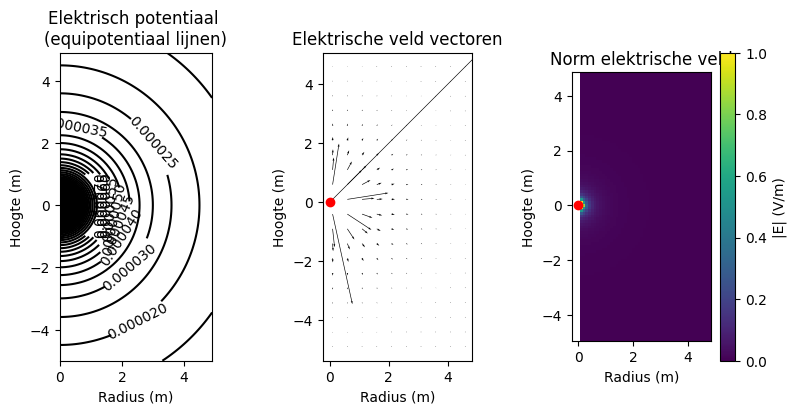

In [2]:
# Run deze cel, pas de cel niet aan
charge_one_point = 1e-14  # lading van 1 punt (C)

r, z, B = initialize_plane_grid_for_pt_charge_at_origin(height_domain, width_domain, grid_step)
V = calculate_V_point_charge_at_origin(charge_one_point, r, z)

Er, Ez, normE = compute_E_pt_charge(V, B, grid_step)  # gebruik de centered finite-difference method
# met Er de r-component, Ez de z-component en normE de norm van het elektrische veld

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_pt_charge_at_origin(Ez, Er, normE, V, r, z, grid_step)


##### Vraag 1a Het potentiaal rond een puntlading

1. Bepaal welke index correspondeert met $z = 0$ m.
2. Plot de log van het potentiaal tegen de log van de straal.
3. Fit de log van het potentiaal met de log van de straal.
4. Print het exponent op een nette manier.

50
49
49


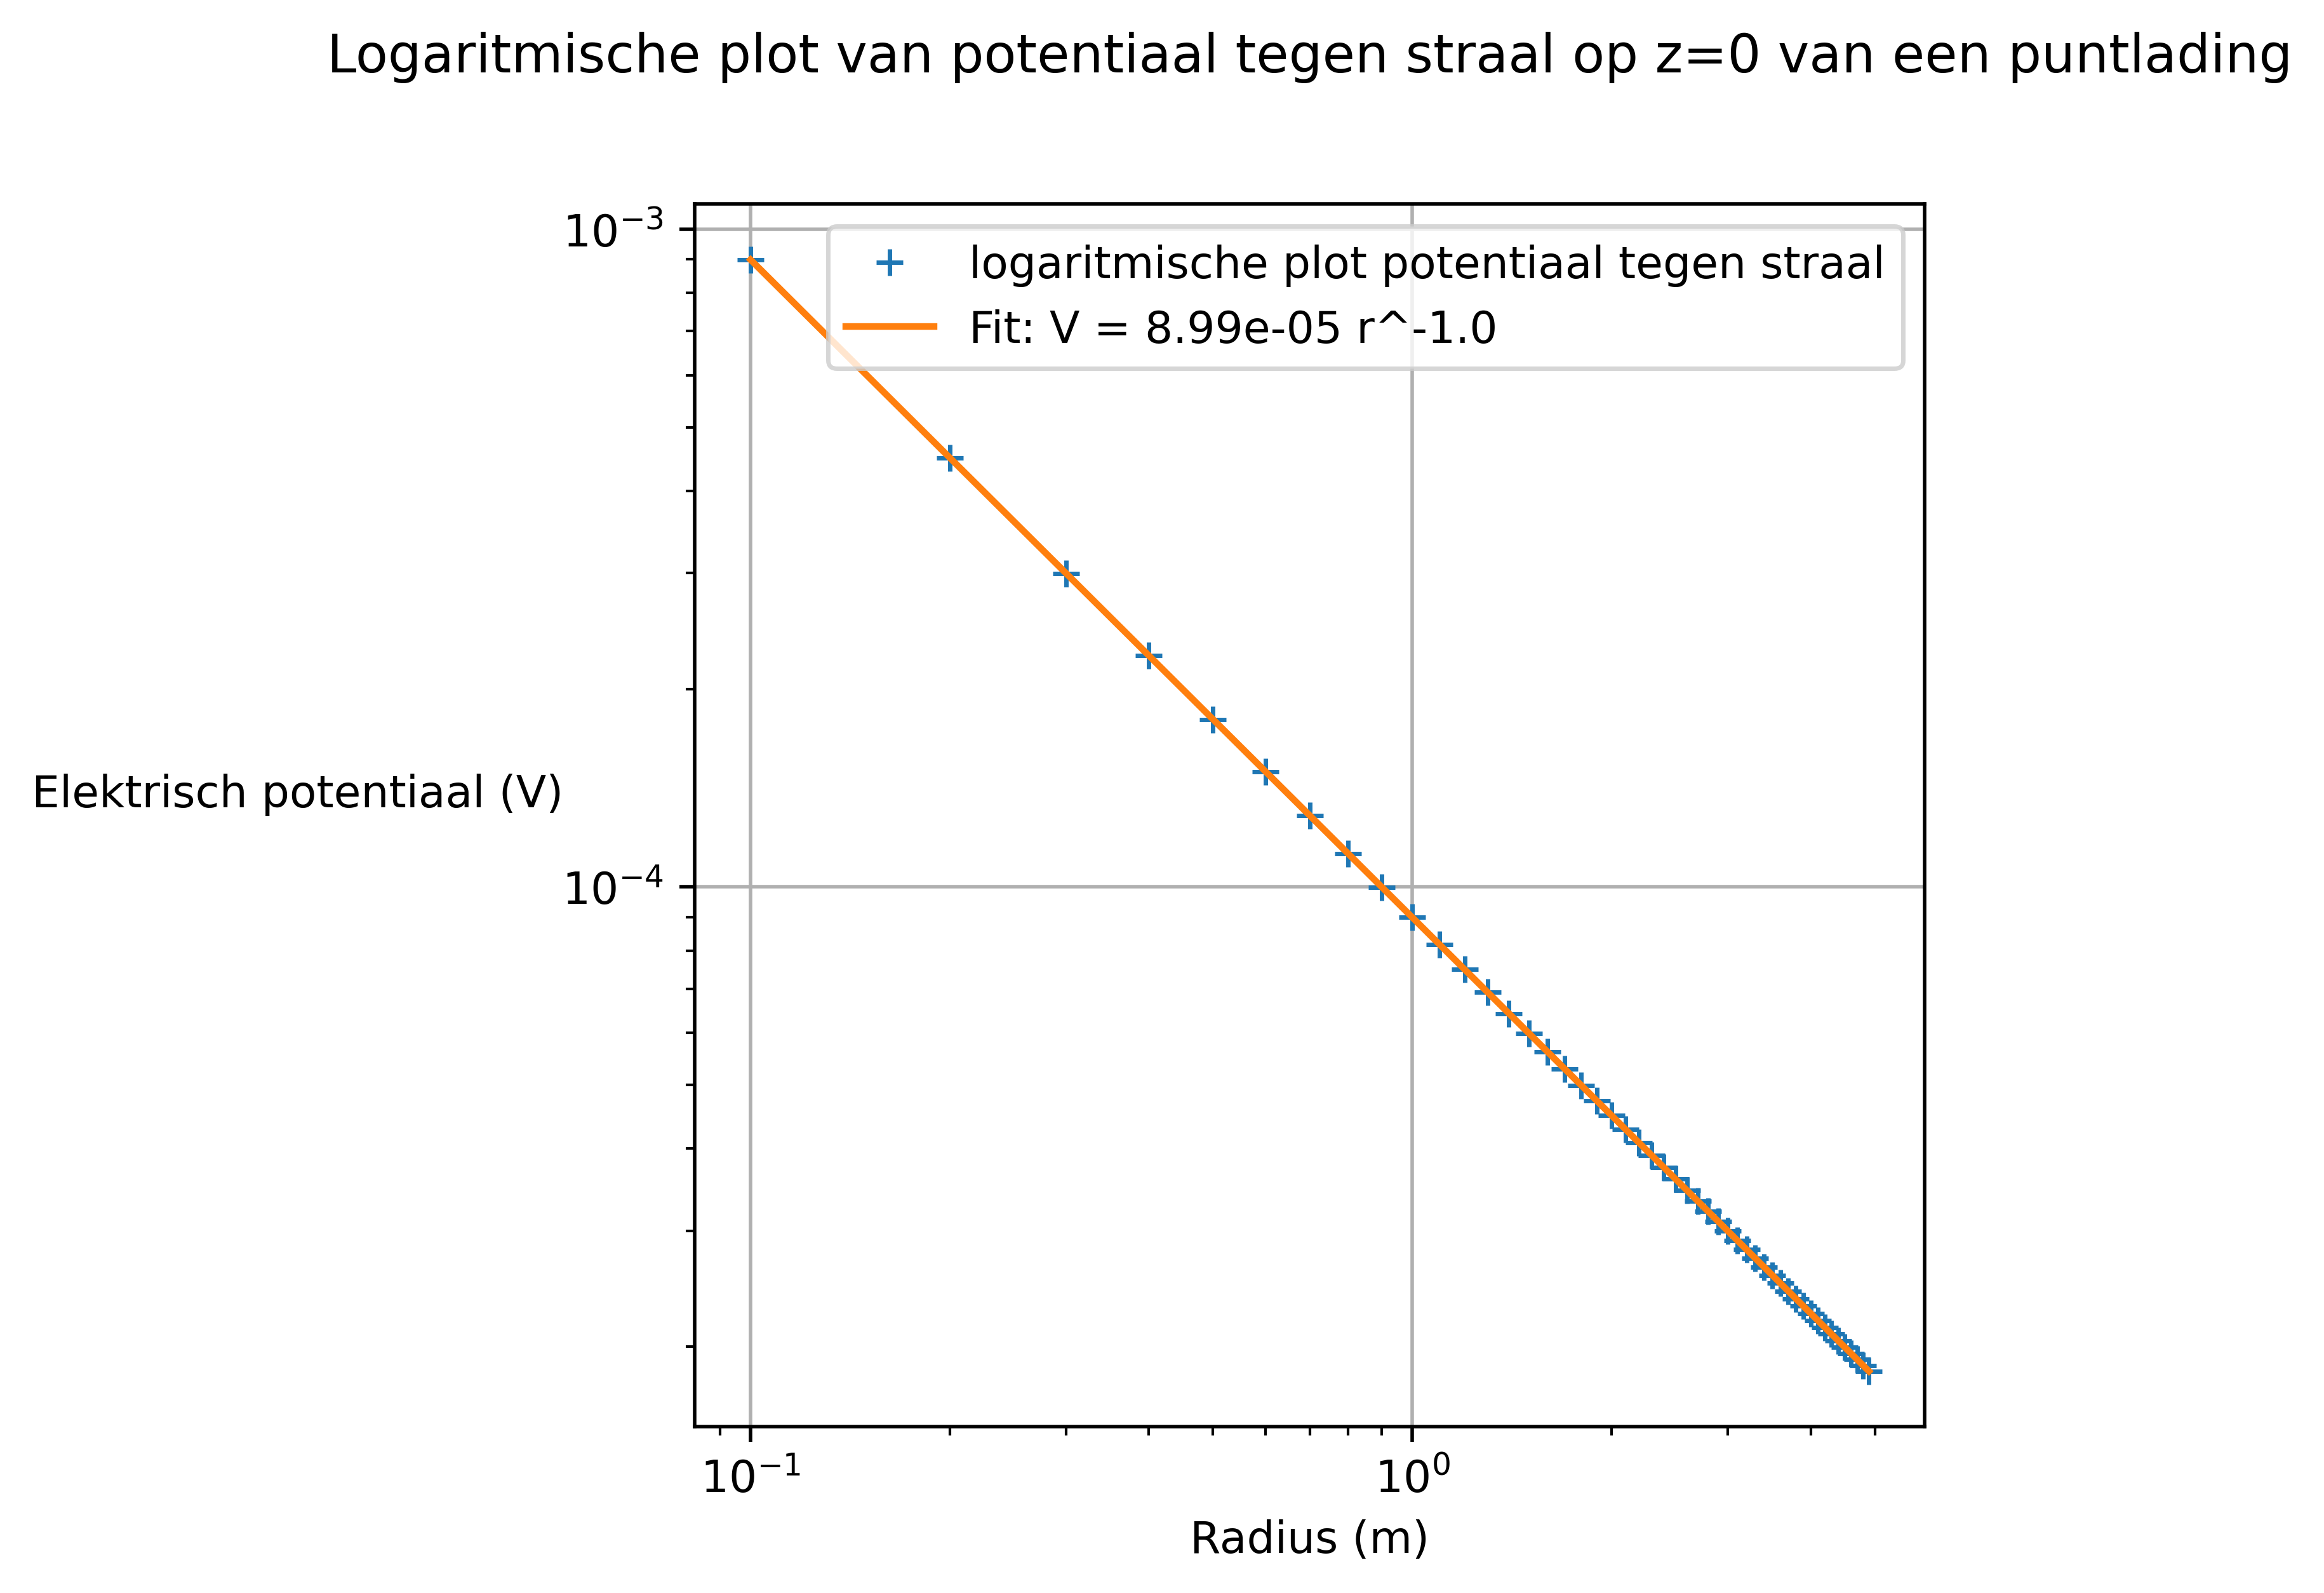

n = -1.0 ± 0.0


In [3]:
###
###Hier jouw code###
# 1
idx_z = find_idx_nearest(z, 0)
print(idx_z)
# 2 
# Uit de matrix van de potentiaal, staat in de kolommen alle potentialen die afhankelijk zijn van de hoogte.
# In de rijen staan alle potentialen die afhankelijk zijn van de straal met constante hoogte.
# Keuze; rij met z=0. Dit is rij 50.
# De r moet niet vanaf het eerste element (0) beginnen, want als je de logaritme neemt aan beide kanten van de potentiaal, krijg je:
# log(V) = log (q/4pie) - log(r), met r ongelijk aan 0.
# Er wordt een verband van V = 1/r verwacht wegens de theorie.
print(len(V[idx_z,1:]))
print(len(r[1:]))
plt.figure(figsize=(5,5), dpi=500)
plt.title('Logaritmische plot van potentiaal tegen straal op z=0 van een puntlading', pad=30)
plt.loglog(r[1:],V[idx_z,1:], '+', label='logaritmische plot potentiaal tegen straal')
plt.xlabel('Radius (m)')
plt.ylabel('Elektrisch potentiaal (V)', rotation=0, labelpad=60)

# 3
# fitten van de log van de potentiaal met log van de straal
from scipy.optimize import curve_fit
x_test = r[1:]
y_test = V[idx_z,1:]

def functionlogpotential(x, loga, n):
    return loga + n * np.log(x)

popt, pcov = curve_fit(functionlogpotential, x_test, np.log(y_test))
loga, n = popt
a = np.exp(loga)
# gefitte lijn plotten
x_fit = np.linspace(min(x_test), max(x_test), 500)
y_fit = a * x_fit**n
plt.loglog(x_fit, y_fit, '-', label=f'Fit: V = {a:.2e} r^{n:.1f}')
plt.legend()
plt.grid()
plt.show()
# 4
u_loga, u_n = np.sqrt(np.diag(pcov))
print(f"n = {n:.1f} ± {u_n:.1f}")
###

##### Vraag 1b Het elektrische veld rond een puntlading
1. Voer van vraag 1a 2 tot 4 uit voor het elektrische veld.

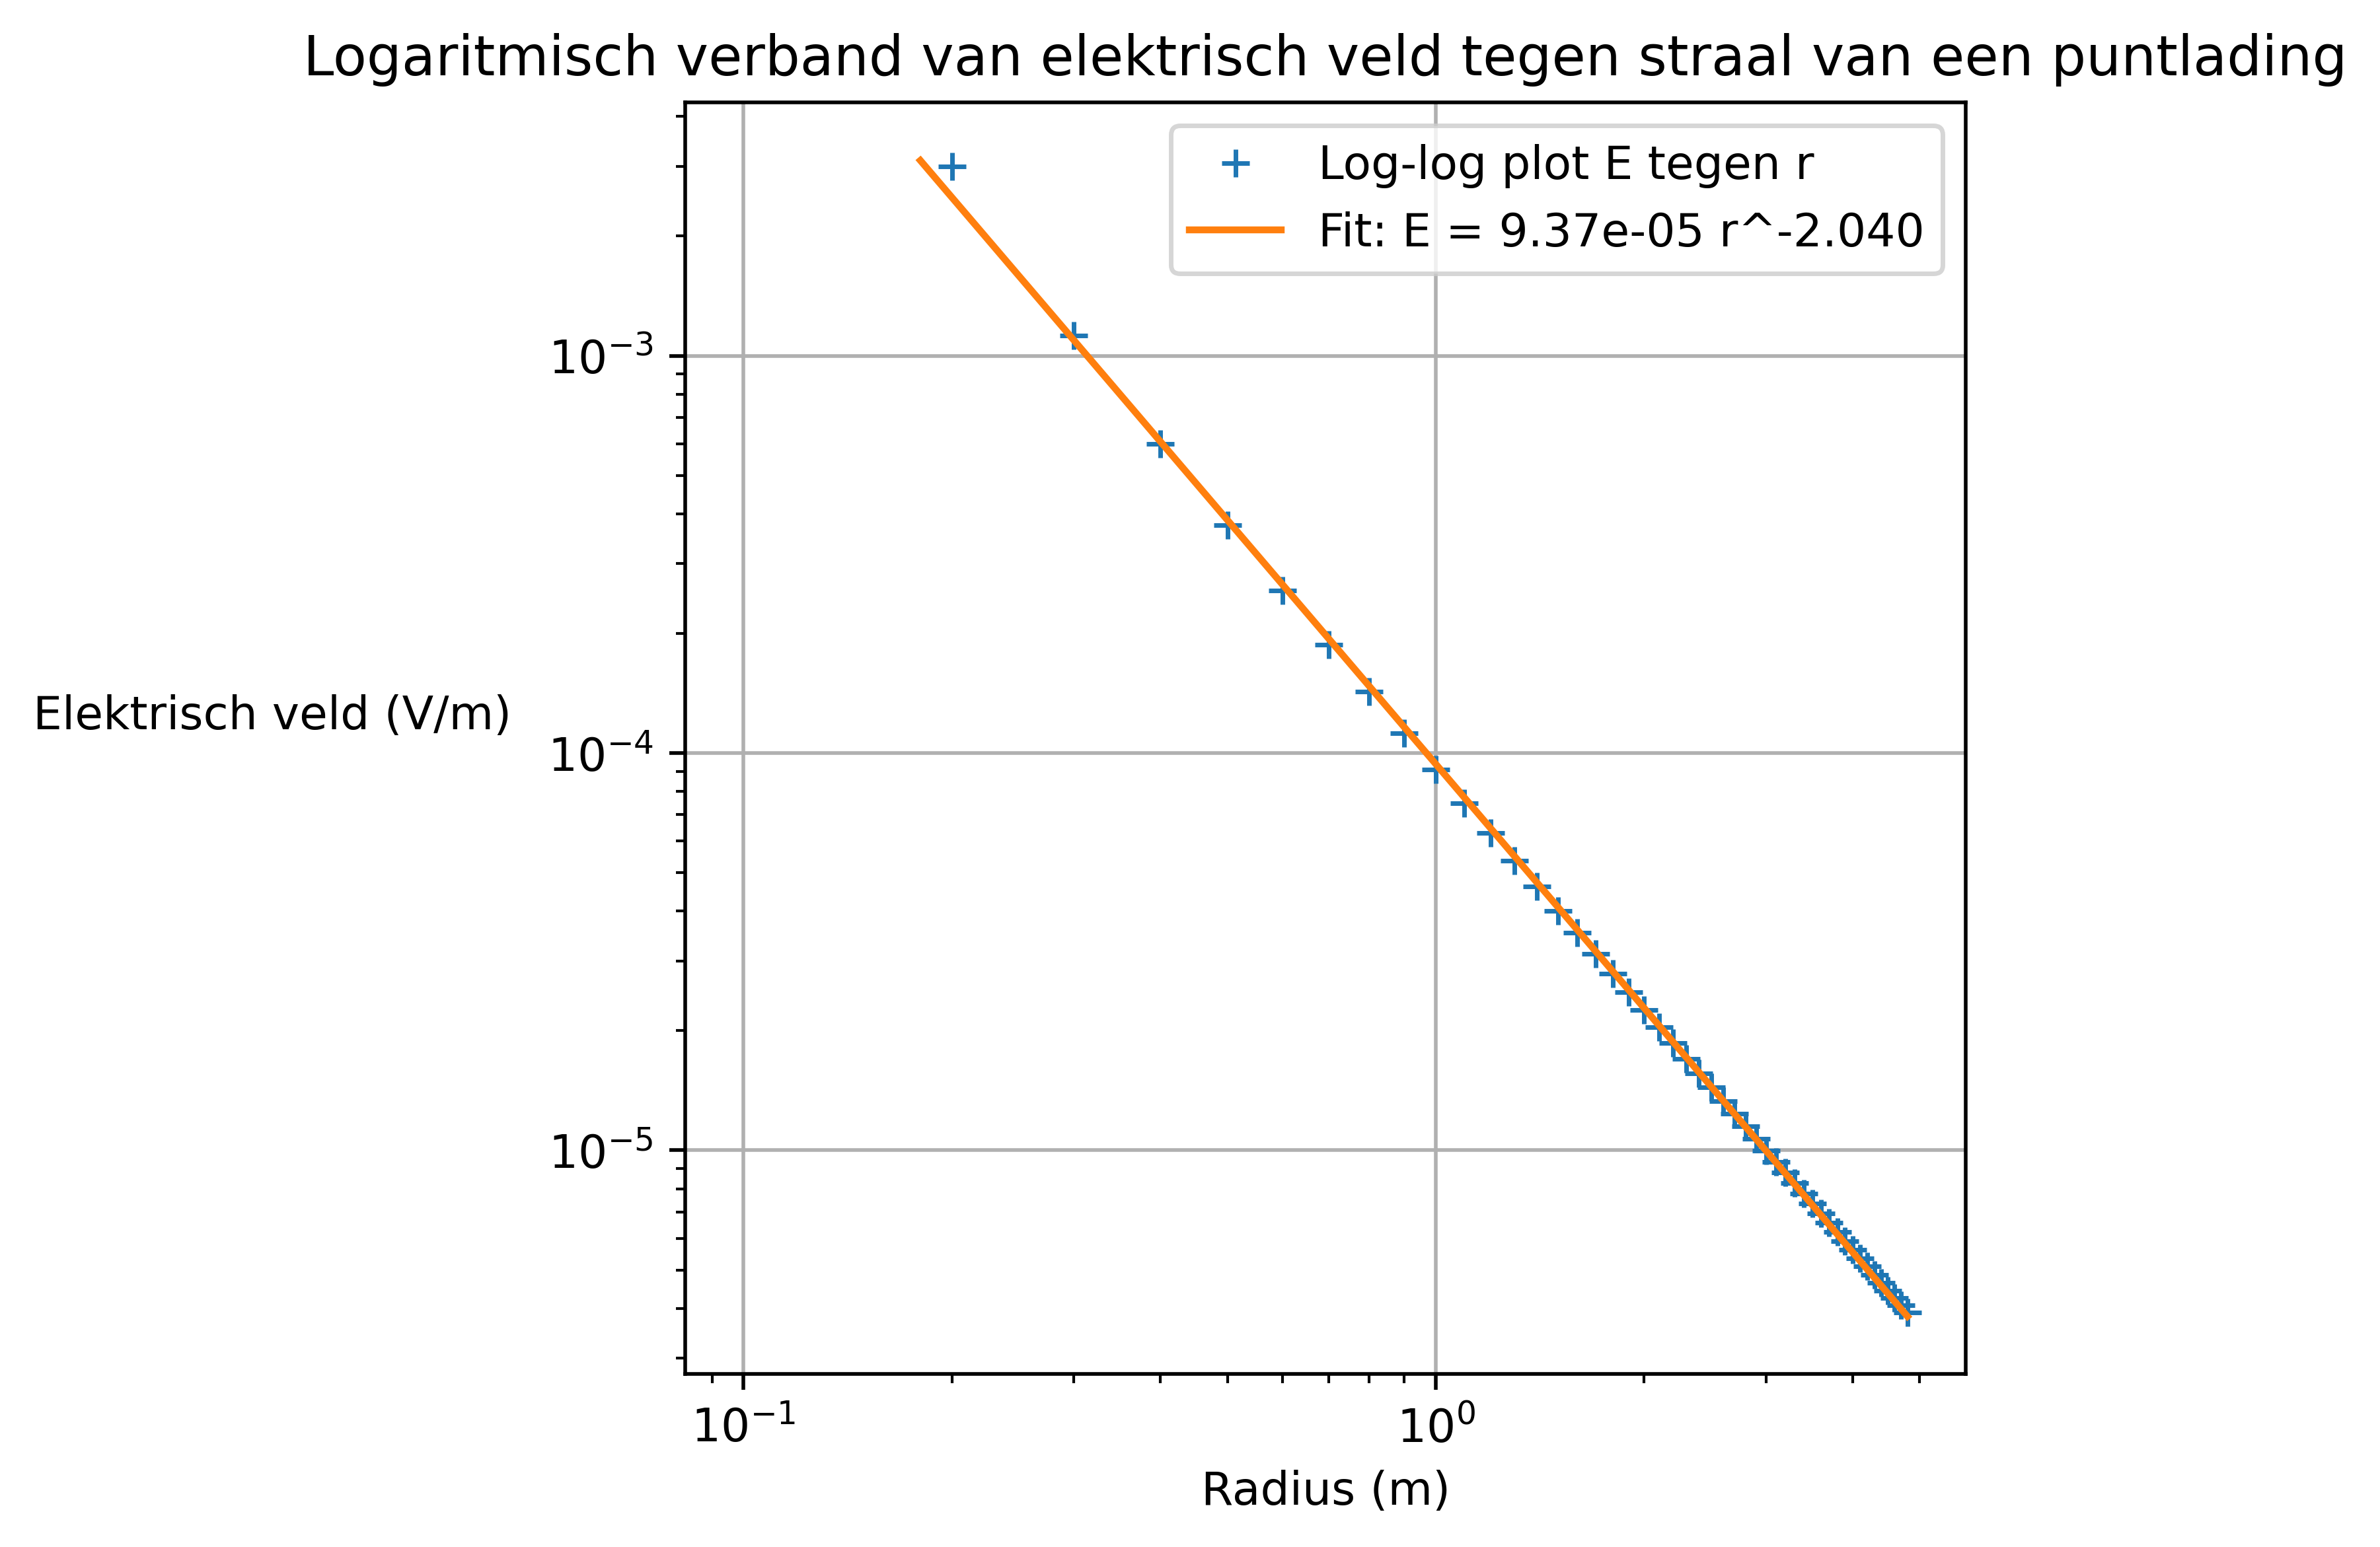

Exponent n = -2.040 ± 0.006


In [4]:
###
###Hier jouw code###
# 2
plt.figure(figsize=(5,5), dpi=500)
# Er is de partieel afgeleide naar r en Ez is de partieel afgeleide naar z.
# De norm_E is de grootte van het elektrisch veld op een positie/ de lengte van de vector op die positie als het ware.
# E = q/ (4pie r^2)
# verwachting; E = 1/r^2
# Omdat V.shape = (Nz, Nr), met rijen 0 tot Nz-1, kolommen 0 tot Nr-1. 
# en normE.shape = (Nz-2, Nr-2), met rijen 0 tot Nz-3, kolommen 0 tot Nr-3.
# In de functie (compute_E_pt_charge) loopt i van 1 tot Nz-2, j van 1 tot Nr-2.
# Dus normE[i-1, j-1] loopt rijen; van 0 tot Nz-1, kolommen; 0 tot Nr-1.
# normE[i-1, j-1] correspondeert met V[i, j]
plt.loglog(r_for_E, normE[idx_z-1 ,:], '+', label='Log-log plot E tegen r')
plt.title('Logaritmisch verband van elektrisch veld tegen straal van een puntlading')
plt.xlabel('Radius (m)')
plt.ylabel('Elektrisch veld (V/m)', rotation=0, labelpad=60)
plt.legend()
plt.grid()
# 3 
from scipy.optimize import curve_fit
def function_log_power(x, loga, n):
    return loga + n*np.log(x)
x_data = r_for_E
y_data = normE[idx_z-1, :]
# om nulpunten (log(0)) te voorkomen moet het elektrisch veld op de randpunten worden weggenomen.
mask = (y_data > 0)
x_fit_data = x_data[mask]
y_fit_data = y_data[mask]

popt, pcov = curve_fit(function_log_power, x_fit_data, np.log(y_fit_data))
loga, n = popt
a = np.exp(loga)
x_fit = np.linspace(0.9*min(x_fit_data), max(x_fit_data), 500)
y_fit = a * x_fit**n

plt.loglog(x_fit, y_fit, '-', label=f'Fit: E = {a:.2e} r^{n:.3f}')
plt.legend()
plt.show()
# Bij een zeer kleine r is de gradiënt van de potentiaal ({dV}/{dr}) extreem steil/ verticaal.
# Hierdoor mist de numerieke benadering de exacte piek, en is de data bij kleine straal iets hoger dan fitlijn.
# Bij de grootste straal in de schijf is als randvoorwaarde: V=0 gesteld.
# De gradiënt (dV/dr) is veel steiler dan theoretisch correct is bij de rand.
# Door lineaire fit op log-log data, wegen de uitersten (beiden theoretisch te hoog) zwaar mee.
# Hierdoor zie je dat de 'normale' datapunten iets onder de fitlijn liggen.
u_loga, u_n = np.sqrt(np.diag(pcov))
print(f"Exponent n = {n:.3f} ± {u_n:.3f}")
###

### 2) Een uniform geladen schijf bestaande uit puntladingen

In de code hieronder wordt een geladen schijf gemaakt via het superpositie principe. Dit wordt gedaan door een rooster van punten in de ruimte te creëren, alle punten die voldoen aan $z = 0$ m en $r < R$ krijgen een lading charge_one_point en vanuit hier wordt het potentiaal bepaald. Hier is de $z$-as de as van de schijf en de r as de afstand tot de $z$-as.



In [5]:
# In vraag 2.1 wordt naar deze cel verwezen.
disk_radius = 3  # (m)
grid_step = 0.1  # (m)
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

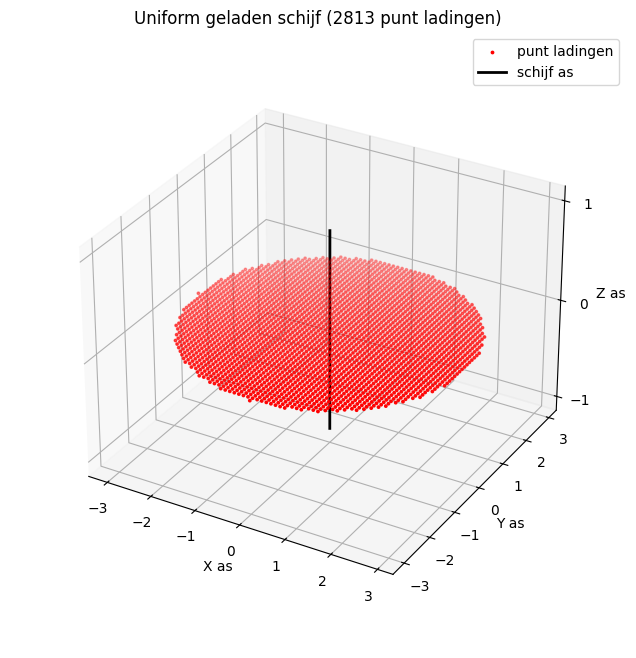

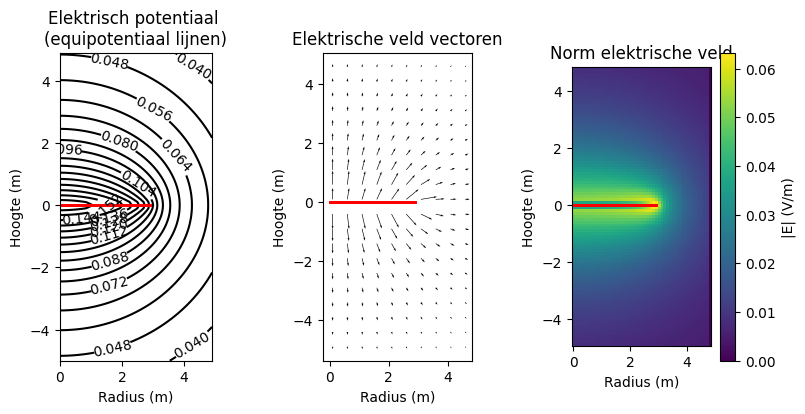

In [6]:
# Kies uit deze cel een van de variabelen en verander die in de cel hierboven pas deze cel zelf niet aan.
r, z, B = initialize_plane_grid_for_uniformly_charged_disk(height_domain, width_domain, grid_step)

idx_z_zero = np.where(abs(z) < 1e-10)[0]    # plek in lijst z waar z=0
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

V, number_point_charges_on_disk = calculate_V_disk_at_origin_uniform_surface_charge_density(z_coord_DISK, charge_one_point, disk_radius, inter_charge_distance, r, z)
Er, Ez, normE = compute_E_disk(V, B, grid_step)  # gebruik de centered finite-difference method

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_coord_DISK, z_coord_DISK)

#### Vraag 2a

In deze vraag gaan jullie achterhalen wat de variabelen die aan het begin van opgave 2 worden geïnitialiseerd betekenen voor de nauwkeurigheid en snelheid van de code.
Pas voor deze vraag de code die net onder het kopje vraag 2 staat aan. Run dan die cel en de cel daaronder opnieuw om het resultaat van je aanpassing te zien.
1. Wat betekent de disk radius variabele die in de bovenste cel geïnitialiseerd wordt, wat gebeurt er als disk radius naar 0 gaat?
2. Wat betekent gridstep en wat voor impact heeft deze variabele op de simulatie?
3. Pak uit de tweede code cel in opdracht 2 een andere variabelen en onderzoek wat deze variabele doet en wat voor impact die heeft op de simulatie.

##### Antwoorden 2a

1. De disk_radius bepaalt de fysieke omvang van de schijf en daarmee het aantal puntladingen in de simulatie. Omdat de oppervlakte van een cirkel wordt berekend met (opp. cirkel=pi * r^2), is het aantal puntladingen kwadratisch evenredig met de straal. Hoe kleiner de disk radius, hoe minder puntladingen er worden geinitialiseerd. Als de disk radius naar 0 gaat, dan wordt er 1 puntlading gecomputeerd. De elektrische veldlijnen vertrekken radiaal vanuit één punt.
2. Hoe groter de grid_step (>0.1), hoe minder puntladingen er in de schijf worden gezet (minder nauwkeurige simulatie) en hoe meer equipotentiaallijnen er worden neergezet. Het ontstaan van meer equipotentiaallijnen is logisch omdat bij variërende positie, de elektrische kracht erg kan verschillen. Er zijn namelijk alleen maar onderling afstotende (positieve) ladingen. Een kleine grid_step (<0.05) vraagt veel computerkracht en is niet uitvoerbaar (simulatie is te traag). Het aantal puntladingen is omgekeerd evenredig met het kwadraat van de grid_step. Wel levert de 'centered finite-difference method' een nauwkeurigere benadering van de continue functie op, en dus benadert deze werkwijze de werkelijkheid veel beter.
3. Ik kijk naar de variabele: z_coord_DISK. Als z_coord_DISK = 0, is het veld symmetrisch boven en onder de schijf. De equipotentiaallijnen zijn dichtbij de schijf plat, maar op grotere afstand worden ze meer halve ovalen en op nog grotere afstand worden het halve cirkels. Naarmate je de schijf verder weg zet van je meetpunten, worden de pijlen van het elektrisch veld in het zichtbare gebied kleiner. Elektrische veldsterkte neemt kwadratisch af met de afstand.

#### Vraag 2b Oppervlakte lading

Pas de cel die je in vraag 2a hebt aangepast weer aan naar de originele waardes. Run hierna alle code cellen na vraag 2 weer opnieuw.
Het aantal punten dat gebruikt wordt om de schijf te creëren is number_point_charges_on_disk en de lading van een punt is charge_one_point in Coulomb.
1. Bereken en print de ladingsdichtheid $\sigma$ met een correcte eenheid.

In [7]:
###
###Hier jouw code###
# de ladingsdichtheid sigma = Q(tot)/A 
# Het is een oppervlakteladingsdichtheid omdat de schijf een oppervlak bestrijkt met een hoogte van 1 puntlading.
# Dus de juiste eenheid is C/(m^2).
# Berekening oppervlakte A
area_disk = np.pi * disk_radius**2      # exact
# Numerieke berekening waarbij het punt alleen meetelt als r<=R. 
# Dit betekent dat je (voor deze specifieke grid_step) stukjes oppervlak aan de rand mist: A(numeriek)<A(exact) 
area_numerical = number_point_charges_on_disk * grid_step**2
print(f"Exact area: {area_disk:.4g} m²")
print(f"Numerical area: {area_numerical:.4g} m²")
# Berekening Q(tot)
total_charge = number_point_charges_on_disk * charge_one_point  # C
# Ladingsdichtheid sigma
sigma = total_charge / area_disk  # C/m^2
print(f"Surface charge density σ: {sigma:.4g} C/m²")
###

Exact area: 28.27 m²
Numerical area: 28.13 m²
Surface charge density σ: 9.949e-13 C/m²


##### Vraag 2c

1. Plot het elektrische potentiaal langs de $r$ as ($z = 0$ m).
2. Plot het potentiaal op de rand van de schijf in hetzelfde figuur $V = \sigma R/(\pi \epsilon_0)$
(bekijk probleem 2.51 in het Griffiths' boek)
3. Plot het potentiaal in het centrum van de schijf in hetzelfde figuur $V = \sigma R/(2 \epsilon_0)$

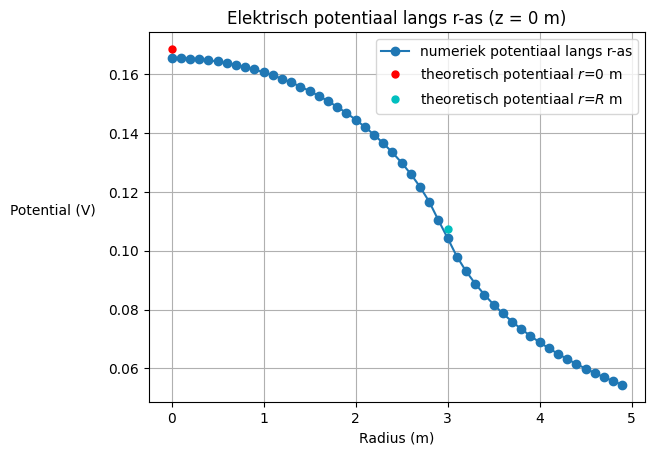

In [8]:
# Vul deze code aan zodat deze vraag 2.3 beantwoord.
idx_z_zero = find_idx_nearest(z, 0) # Vind index van z die het dichtst bij 0 ligt
# potentiaal op z=0
V_r_axis = V[idx_z_zero, :]            # neem alle r-waarden
# voor ideale continu uniforme schijf
V_0 = (sigma * disk_radius) /(2 * epsilon0)   # potentiaal op r = 0
# ideale continu uniforme schijf
V_R = (sigma * disk_radius) /(np.pi * epsilon0) # potentiaal op de straal/rand van de schijf 
r_R = disk_radius # straal van de schijf


plt.title(f"Elektrisch potentiaal langs r-as (z = 0 m)")
plt.plot(r, V_r_axis, "o-", label="numeriek potentiaal langs r-as")
#plt.plot(r, V, "o-", label="numeriek potentiaal")
plt.plot(0, V_0, "r.", markersize=10, label="theoretisch potentiaal $r$=0 m")
plt.plot(r_R, V_R, "c.", markersize=10, label="theoretisch potentiaal $r$=$R$ m")
plt.legend()
plt.xlabel("Radius (m)")
plt.ylabel("Potential (V)", rotation=0, labelpad=40)
plt.grid()
plt.show()
# Elk punt is een puntlading, geen continu oppervlak. 
# Omdat aan de randen de middelpunten van de vierkantjes volledig binnen de straal moeten passen, verlies je daar in de simulatie oppervlak.
# De numerieke oppervlakte is daardoor iets kleiner dan de exacte (wegens gekozen grid_step).
# Dus totale som van ladingen is iets kleiner dan theoretische lading over continu verdeelde ladingen over cirkel.
# Hoe kleiner de grid_step, hoe beter de numerieke som de integraal over oppervlak benadert.

#### Vraag 2d

Het theoretische potentiaal op de as van een hele grote schijf ($R>>z$) is:
$V(z, r=0) = \frac{\sigma}{2\epsilon_0} \big( R - |z|\big)$
zie probleem 2.26 in het Griffiths boek.
1. Plot het numeriek berekend elektrische potentiaal op de $z$-as ($r=0$).
2. Plot het theoretische component van het potentiaal op de as van een schijf met ladingsdichtheid $\sigma$.
3. Sla deze plot op.



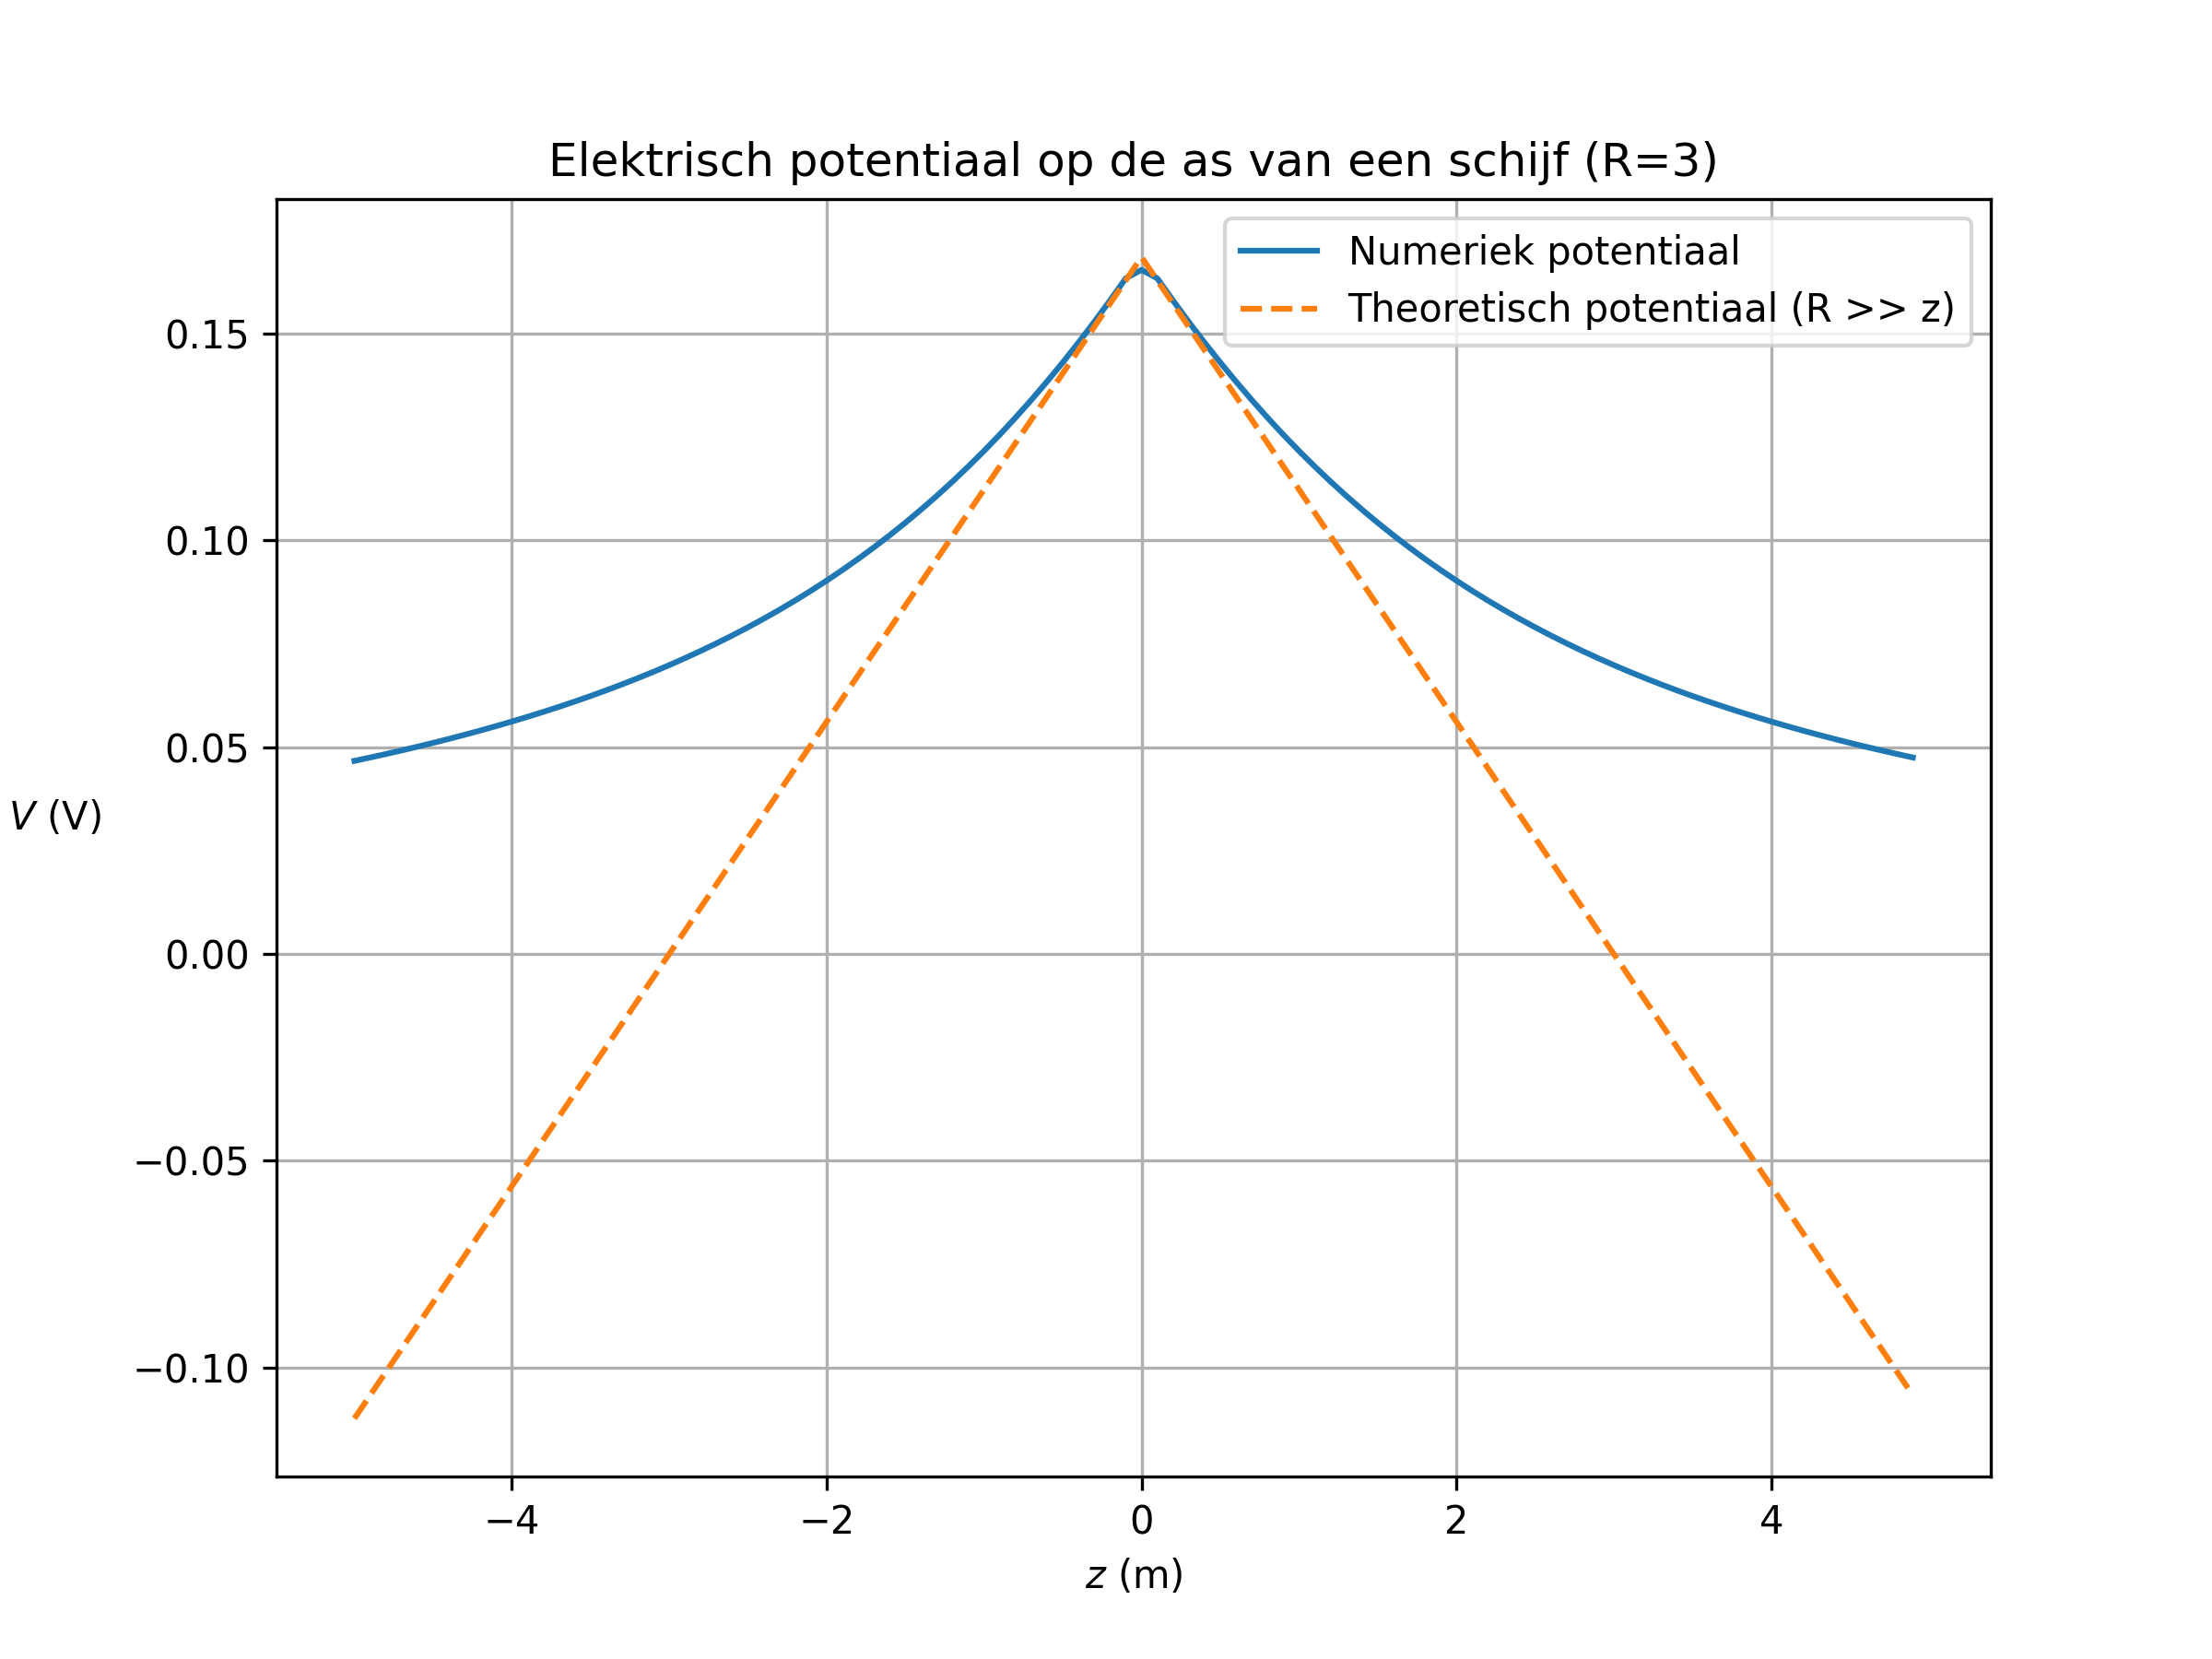

In [9]:
###
###Hier jouw code###
# numeriek berekende potential op r=0
idx_r_zero = find_idx_nearest(0, r) # Vind index van r die het dichtst bij 0 ligt
# potentiaal op r=0
V_z_axis = V[:, idx_r_zero]            # neem alle z-waarden

# theoretische potential
V_theory = (sigma / (2 * epsilon0)) * (disk_radius - np.abs(z))

# Plotten
plt.figure(figsize=(8,6))
plt.plot(z, V_z_axis, label='Numeriek potentiaal')
plt.plot(z, V_theory, '--', label='Theoretisch potentiaal (R >> z)')
plt.xlabel('$z$ (m)')
plt.ylabel('$V$ (V)', rotation=0, labelpad=20)
plt.title('Elektrisch potentiaal op de as van een schijf (R=3)')
plt.legend()
plt.grid(True)
plt.savefig('potentiaal_schijf_op_as_van_schijf_DR3.png', dpi=300)
plt.close()
display(Image("C:/Users/Eline/OneDrive/Documents/opdrachten-DEF-D.EALSerpenti/DigitaleOntwerpopdrachten/1CondensatorOpdracht/potentiaal_schijf_op_as_van_schijf_DR3.png"))
# Voor R >> |z| liggen de numerieke en theoretische waarden vrijwel op elkaar.
# Naarmate z groter wordt, zal de numerieke curve iets minder lineair afnemen dan de theoretische benadering
# omdat theoretische formule een schijf met “oneindige” straal aanneemt.
###

#### Vraag 2e

Het theoretische elektrische veld van een oneindig geladen oppervlakte is $|E| = \sigma/(2 \epsilon_0)$ (zie Example 2.5 in het Griffith boek).
1. Plot het z-component van het numeriek berekende elektrische veld op de as van de schijf ($r=0$).
2. Plot het theoretische elektrische veld voor een oneindig geladen oppervlak.
3. Sla deze plot ook op.

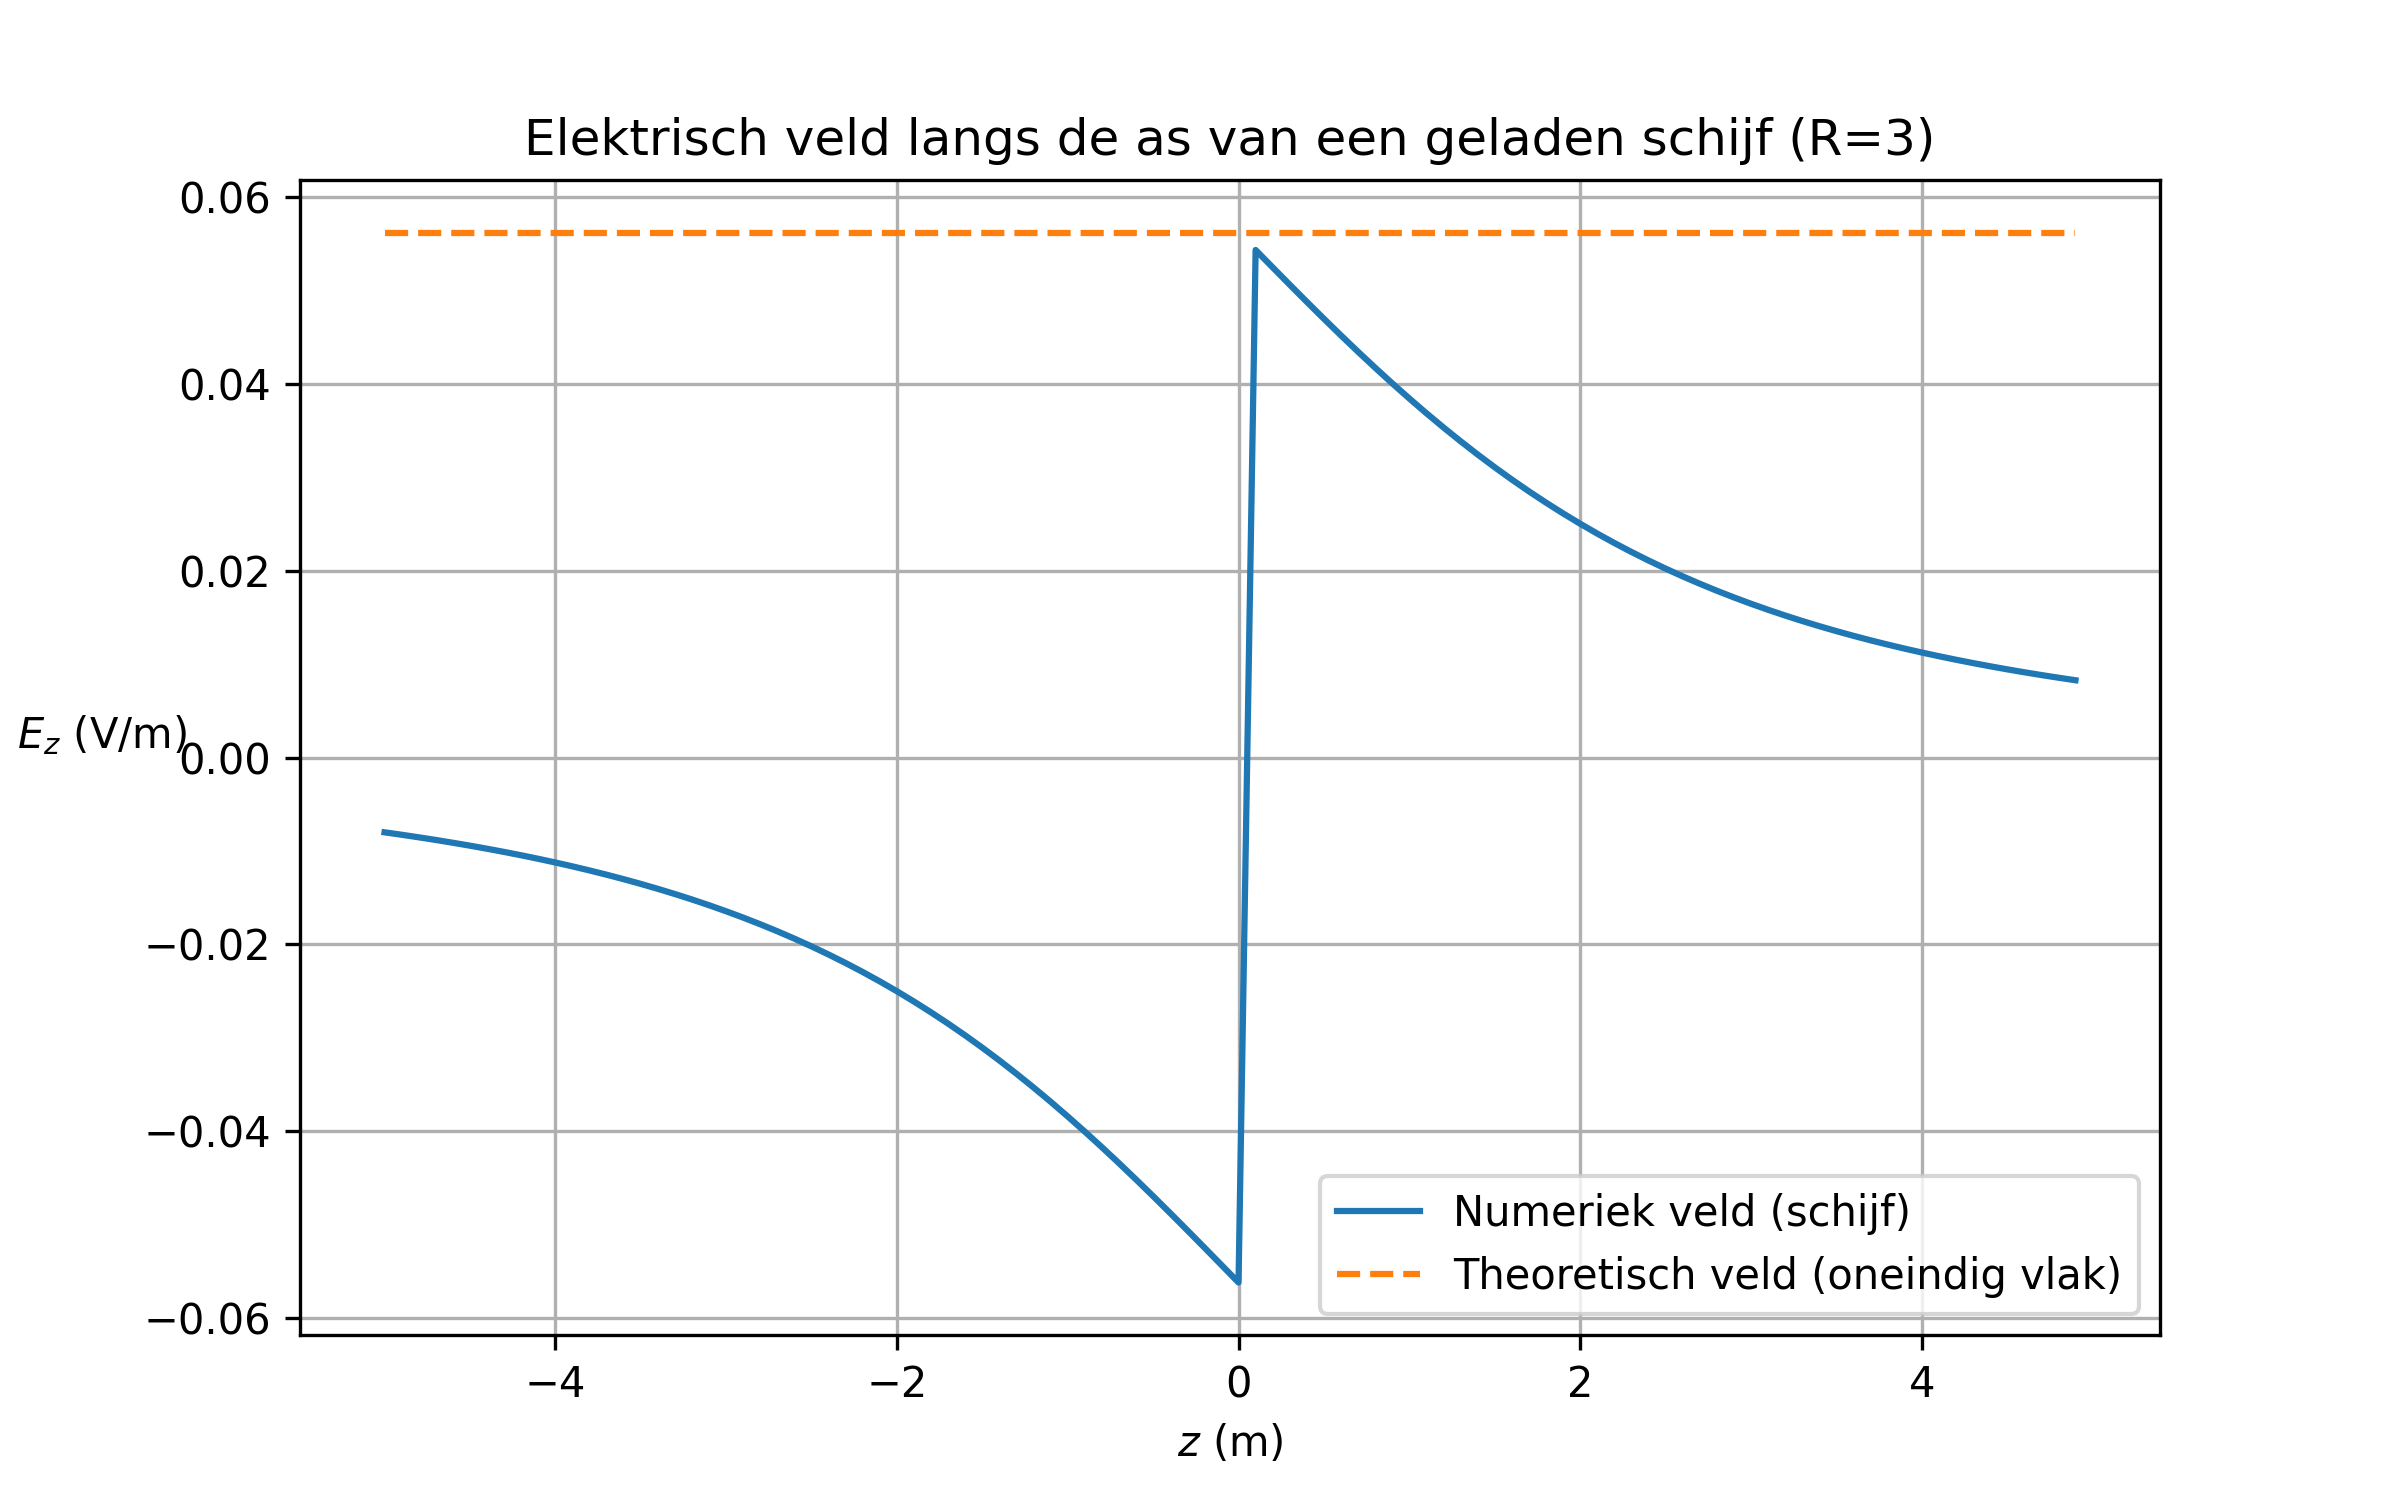

In [10]:
###
###Hier jouw code###
# Numeriek veld van een eindige schijf
# De z-component van elektrisch veld op r=0:
# Schijf onderverdeeld in ringen, opp(ring) = 2pi* r * dr 
# dq = sigma* dA
# Voor puntlading: dE = dq/(4 * pi * epsilon0 * s^2) met s = wortel(z^2 + r^2)
# z-component van het elektrisch veld bereken je door te vermenigvuldigen met cos(theta)= z/s
# dE(z)= (z * sigma * r * dr)/(2*epsilon0* (z^2 + r^2)^3/2)
# Dit integreren van r=0 tot r=R: (sigma / (2 * epsilon0)) * (1 - z/np.sqrt(disk_radius**2 + z**2)) 
# np.sign(z) staat erbij omdat het elektrisch veld natuurlijk van teken wisselt o.b.v positie boven of onder de schijf.
Ez_numeriek = (sigma/(2*epsilon0)) * (np.sign(z) - z/np.sqrt(disk_radius**2 + z**2))
# voor R->oneindig, blijft inderdaad over: Ez= (sigma / (2 * epsilon0)
# theoretische elektrisch veld voor oneindig geladen oppervlak (oneindige straal)
E_theoretical = sigma/(2*epsilon0) * np.ones_like(z) # zelfde dimensie
# Plotten
plt.figure(figsize=(8,5))
plt.plot(z, Ez_numeriek, label='Numeriek veld (schijf)')
plt.plot(z, E_theoretical, '--', label='Theoretisch veld (oneindig vlak)')
plt.xlabel('$z$ (m)')
plt.ylabel('$E_z$ (V/m)', rotation=0, labelpad=10)
plt.title('Elektrisch veld langs de as van een geladen schijf (R=3)')
plt.legend()
plt.grid(True)
plt.savefig('elektrisch_veld_op_as_van_schijf_DR3.png', dpi=300) 
plt.close()
display(Image("C:/Users/Eline/OneDrive/Documents/opdrachten-DEF-D.EALSerpenti/DigitaleOntwerpopdrachten/1CondensatorOpdracht/elektrisch_veld_op_as_van_schijf_DR3.png"))
###

#### Vraag 2f
1. Waar benadert het elektrische veld van een uniform geladen schijf dat van een oneindig geladen plaat?
2. Beschrijf en verklaar de verschillen die je opvallen in de plot die je bij vraag 2e hebt gemaakt.

##### Antwoorden 2f

1. Als z->0+, benadert het elektrisch veld van een uniform geladen schijf dat van een oneindig geladen plaat. Dis logisch, want voor z->0+ reduceert Ez_numeriek tot E_theoretical. Voor z->0- benadert Ez_numeriek -E_theoretical.
2. E_theoretical komt voort uit Ez_numeriek. Bij R->oneindig van Ez_numeriek, blijft inderdaad over: Ez= sigma / (2 * epsilon0). Deze functie is onafhankelijk van zowel disk_radius als z. Dit vormt een rechte lijn in de plot. Ez_numeriek is afhankelijk van de verhouding tussen disk_radius en z. Als de z groter dan de schijfhoogte is, zorgt tekenconventie voor een positief elektrisch veld en andersom. Dichtbij de schijfhoogte (z=0), is abs(Ez) het grootst. Bij abs(z) nadert Ez 0.

#### Vraag 2g

1. Pas helemaal bovenaan in vraag 2 de straal van de schijf aan.
2. Voer dan vragen 2d en 2e opnieuw uit.
3. Voeg de opgeslagen figuren hieronder toe.
4. Beschrijf de verschillen tussen de twee verschillende stralen.

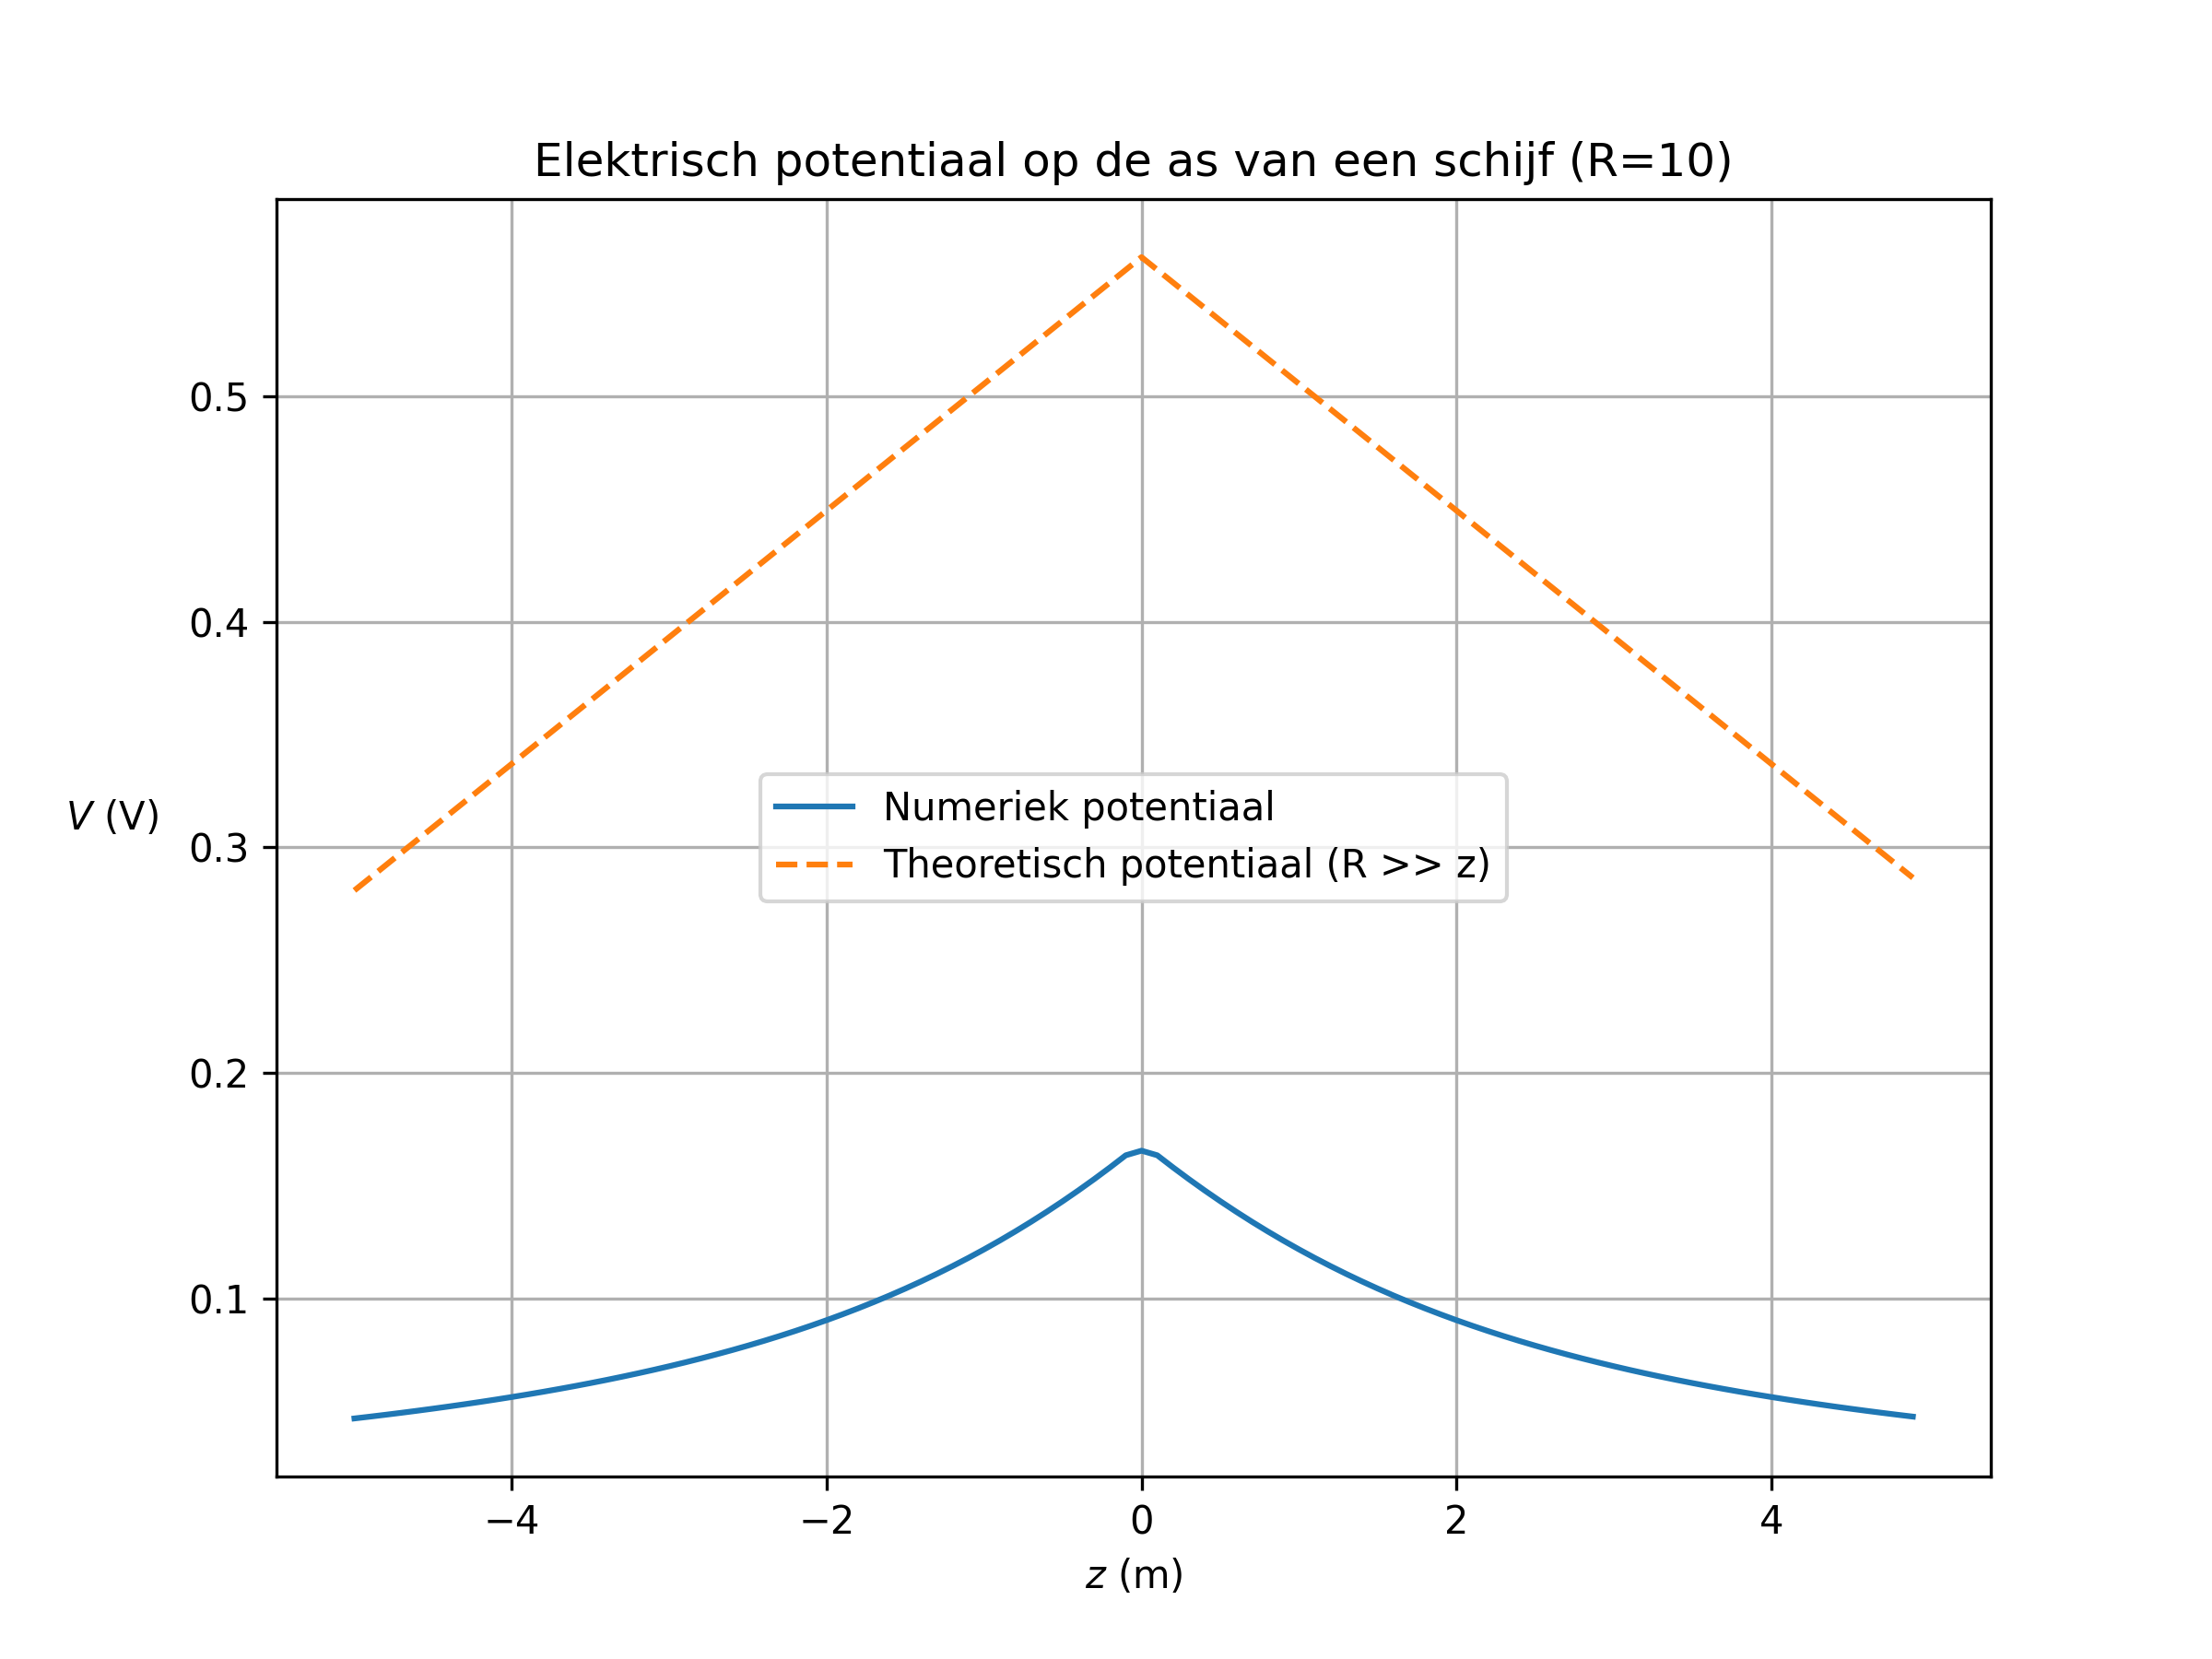

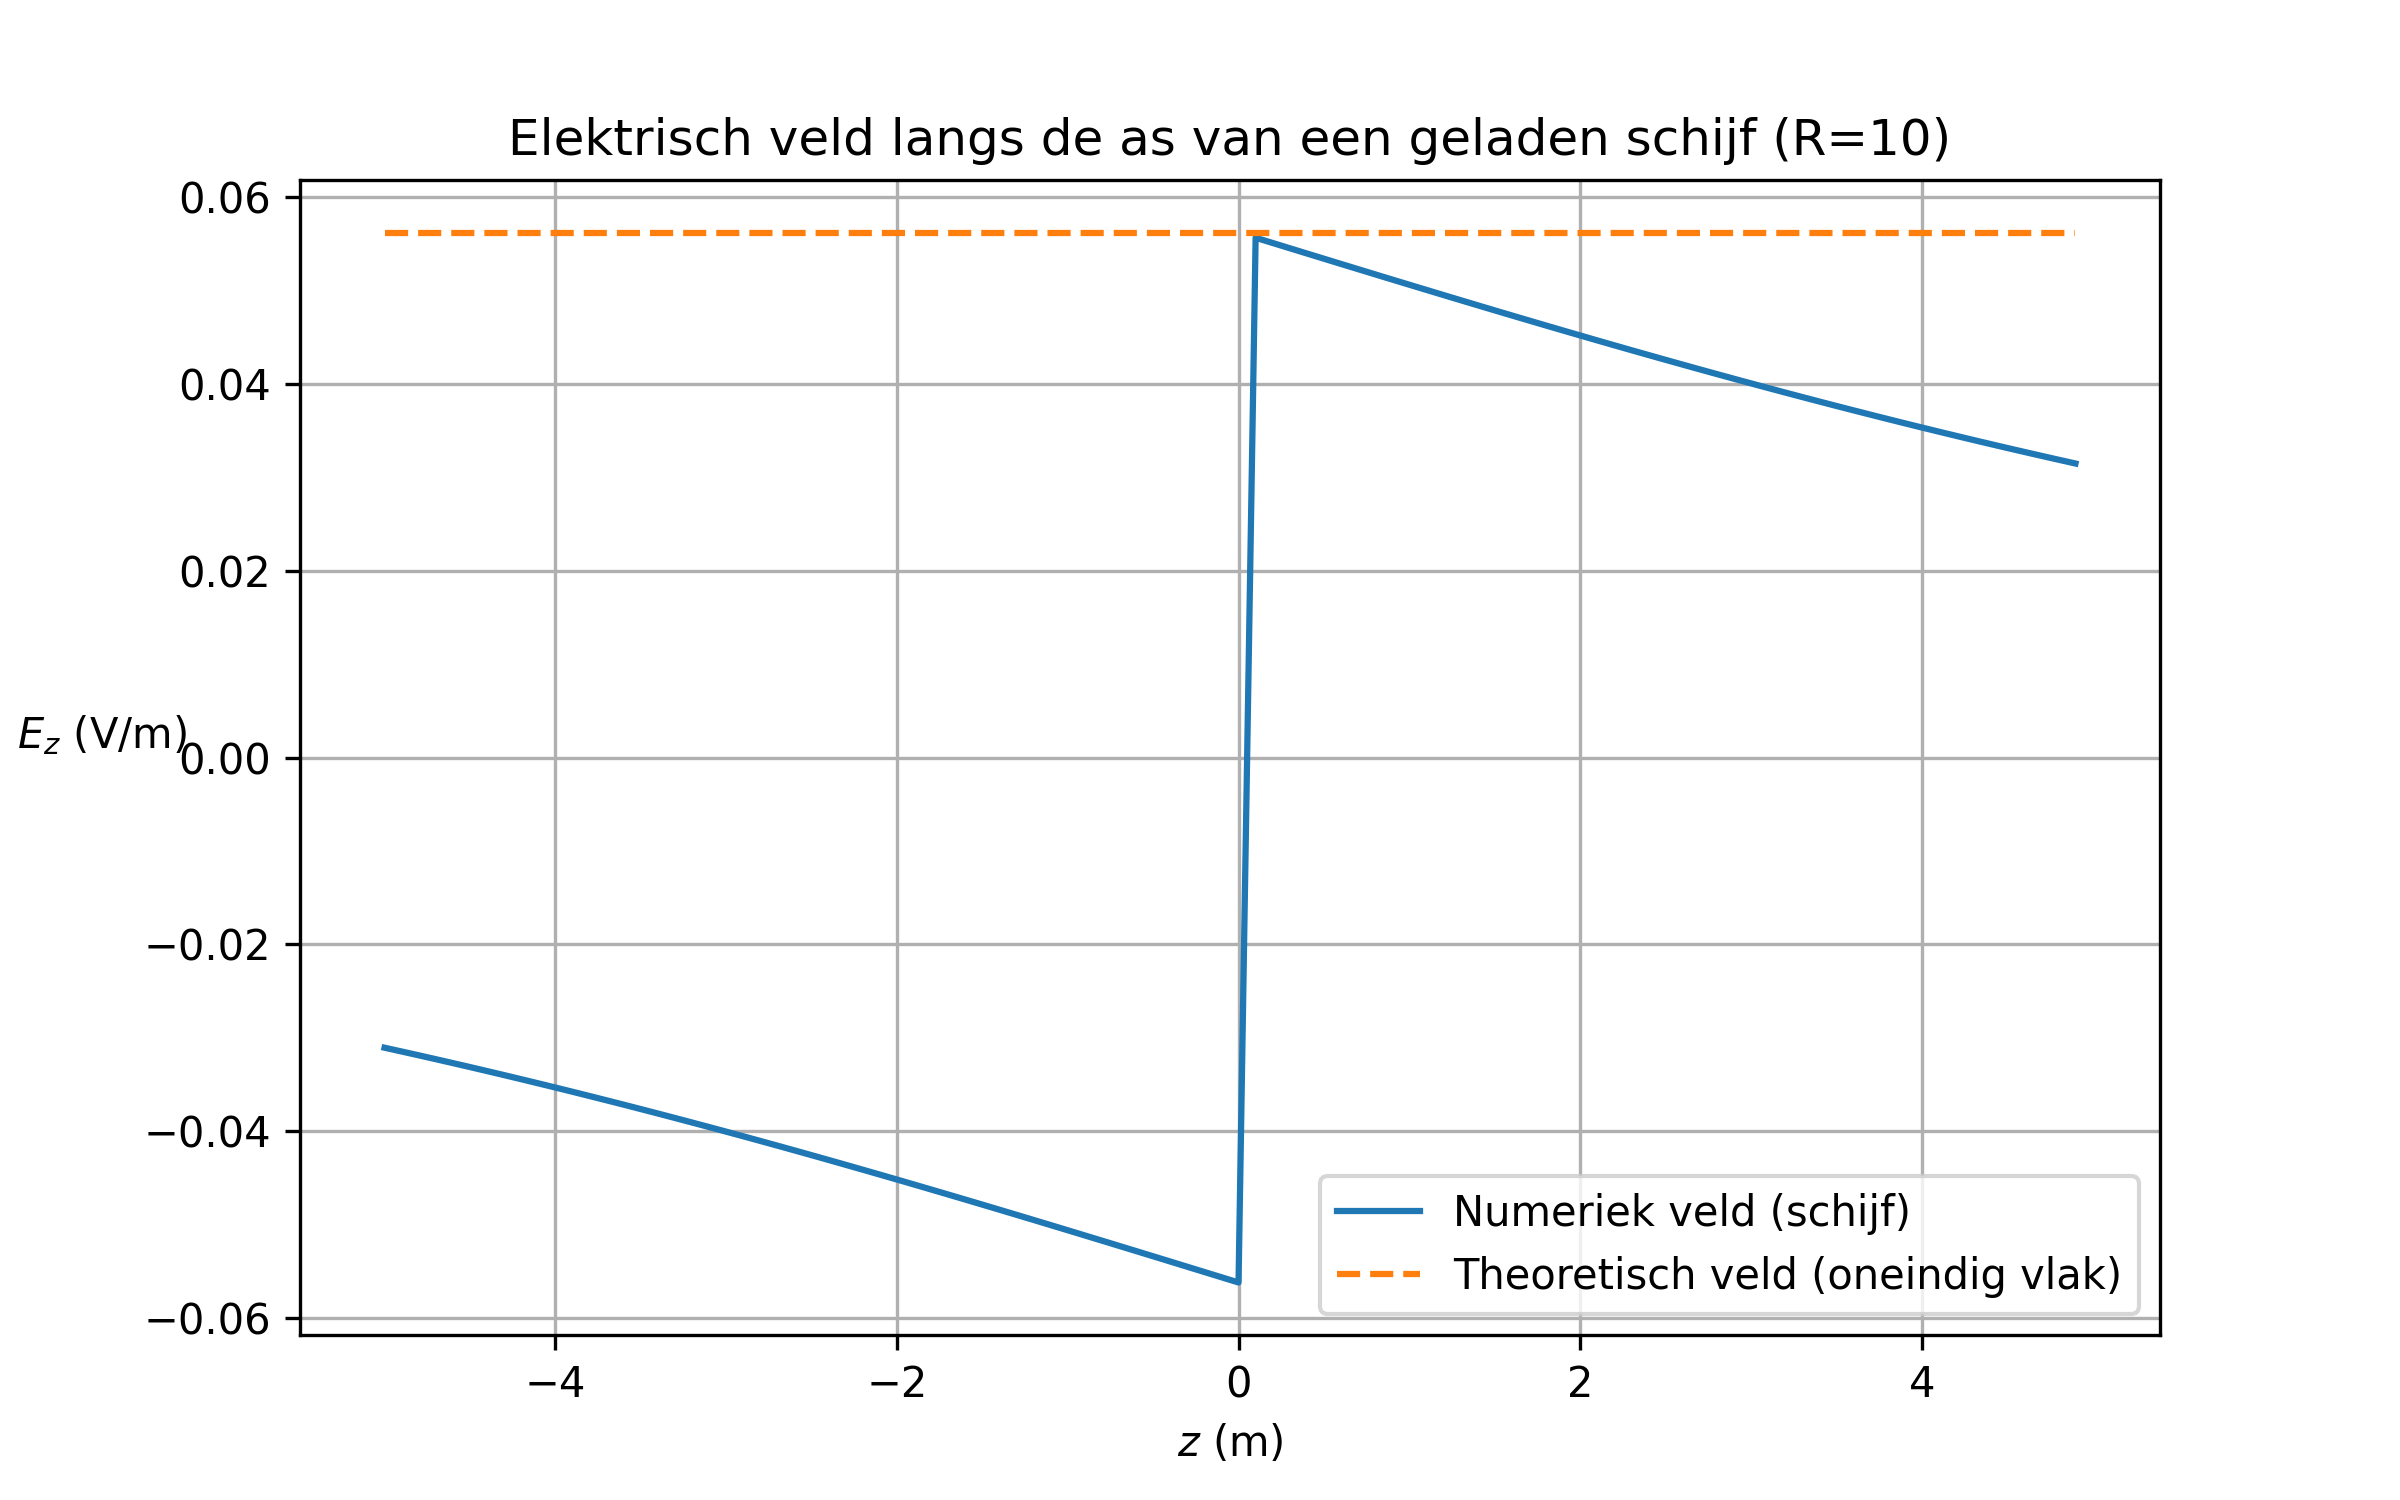

In [11]:
###
###Jouw code hier###    
disk_radius2 = 10
# 2d
# theoretische potential
V_theory = (sigma / (2 * epsilon0)) * (disk_radius2 - np.abs(z))

plt.figure(figsize=(8,6))
plt.plot(z, V_z_axis, label='Numeriek potentiaal')
plt.plot(z, V_theory, '--', label='Theoretisch potentiaal (R >> z)')
plt.xlabel('$z$ (m)')
plt.ylabel('$V$ (V)', rotation=0, labelpad=20)
plt.title('Elektrisch potentiaal op de as van een schijf (R=10)')
plt.legend()
plt.grid(True)
plt.savefig('potentiaal_schijf_op_as_van_schijf_DR10.png', dpi=300)
plt.close()

# 2e
Ez2 = (sigma/(2*epsilon0))*(np.sign(z) - z/np.sqrt(disk_radius2**2 + z**2))

plt.figure(figsize=(8,5))
plt.plot(z, Ez2, label='Numeriek veld (schijf)')
plt.plot(z, E_theoretical, '--', label='Theoretisch veld (oneindig vlak)')
plt.xlabel('$z$ (m)')
plt.ylabel('$E_z$ (V/m)', rotation=0, labelpad=10)
plt.title('Elektrisch veld langs de as van een geladen schijf (R=10)')
plt.legend()
plt.grid(True)
plt.savefig('elektrisch_veld_op_as_van_schijf_DR10.png', dpi=300) 
plt.close()
###
# 2d
display(Image("C:/Users/Eline/OneDrive/Documents/opdrachten-DEF-D.EALSerpenti/DigitaleOntwerpopdrachten/1CondensatorOpdracht/potentiaal_schijf_op_as_van_schijf_DR10.png"))
# 2e
display(Image("C:/Users/Eline/OneDrive/Documents/opdrachten-DEF-D.EALSerpenti/DigitaleOntwerpopdrachten/1CondensatorOpdracht/elektrisch_veld_op_as_van_schijf_DR10.png"))

##### Antwoorden 2g

De theoretische potentiaal bij een straal van 10 blijft positief voor het gegeven domein van z, terwijl de theoretische potentiaal bij een straal van 3 ook negatief wordt bij zeer hoge en zeer lage z-waarden. Dit is logisch, want dit komt voort uit de formule voor de theoretische potentiaal: $V(z, r=0) = \frac{\sigma}{2\epsilon_0} \big( R - |z|\big)$. Ook is de knik/ de maximale waarde van V groter bij R=10 dan bij R=3. 

V numeriek langs de as ligt nog dichter bij de theoretische rechte lijn voor R≫z/ V_numeriek is bijna lineair zoals theoretisch. De numerieke potentiaal bij R=10 is gladder dan de numerieke potentiaal bij R=3. Bij een kleine straal daalt het potentiaal sneller met z en wordt minder “vlak” dichtbij de schijf, omdat er minder lading is om het potentiaal constant te houden.

Voor grote R blijft het elektrisch veld bijna constant dicht bij de schijf, zoals bij een oneindig geladen vlak. Bij z->0+ is het Ez2 = E theoretical. Voor kleine R neemt het veld sneller af met z. het bereikt nooit de constante waarde van 𝜎/ (2epsilon0).

#### Vraag 2h
Het elektrische veld een afstand $z$ boven het midden van een uniform geladen schijf met een straal $R$ en oppervlakte lading $\sigma$ wordt gegeven door:
$$ \mathbf{E} = \frac{\sigma}{2\epsilon_0} \bigg[ 1- \frac{z}{\sqrt{R^2 + z^2}}\bigg] \hat{\mathbf{z}}$$
Zie probleem 2.6 in het boek van Griffith.

1. Wat moet de hoogte $z$ zijn boven de schijf zodat het elektrische veld door de schijf 10% is in vergelijking met dat van een oneindig geladen plaat?

Voeg hieronder je analytische uitwerking toe.

##### Antwoord 2h

![WhatsApp Image 2026-03-02 at 17.39.50.jpeg](<attachment:WhatsApp Image 2026-03-02 at 17.39.50.jpeg>)
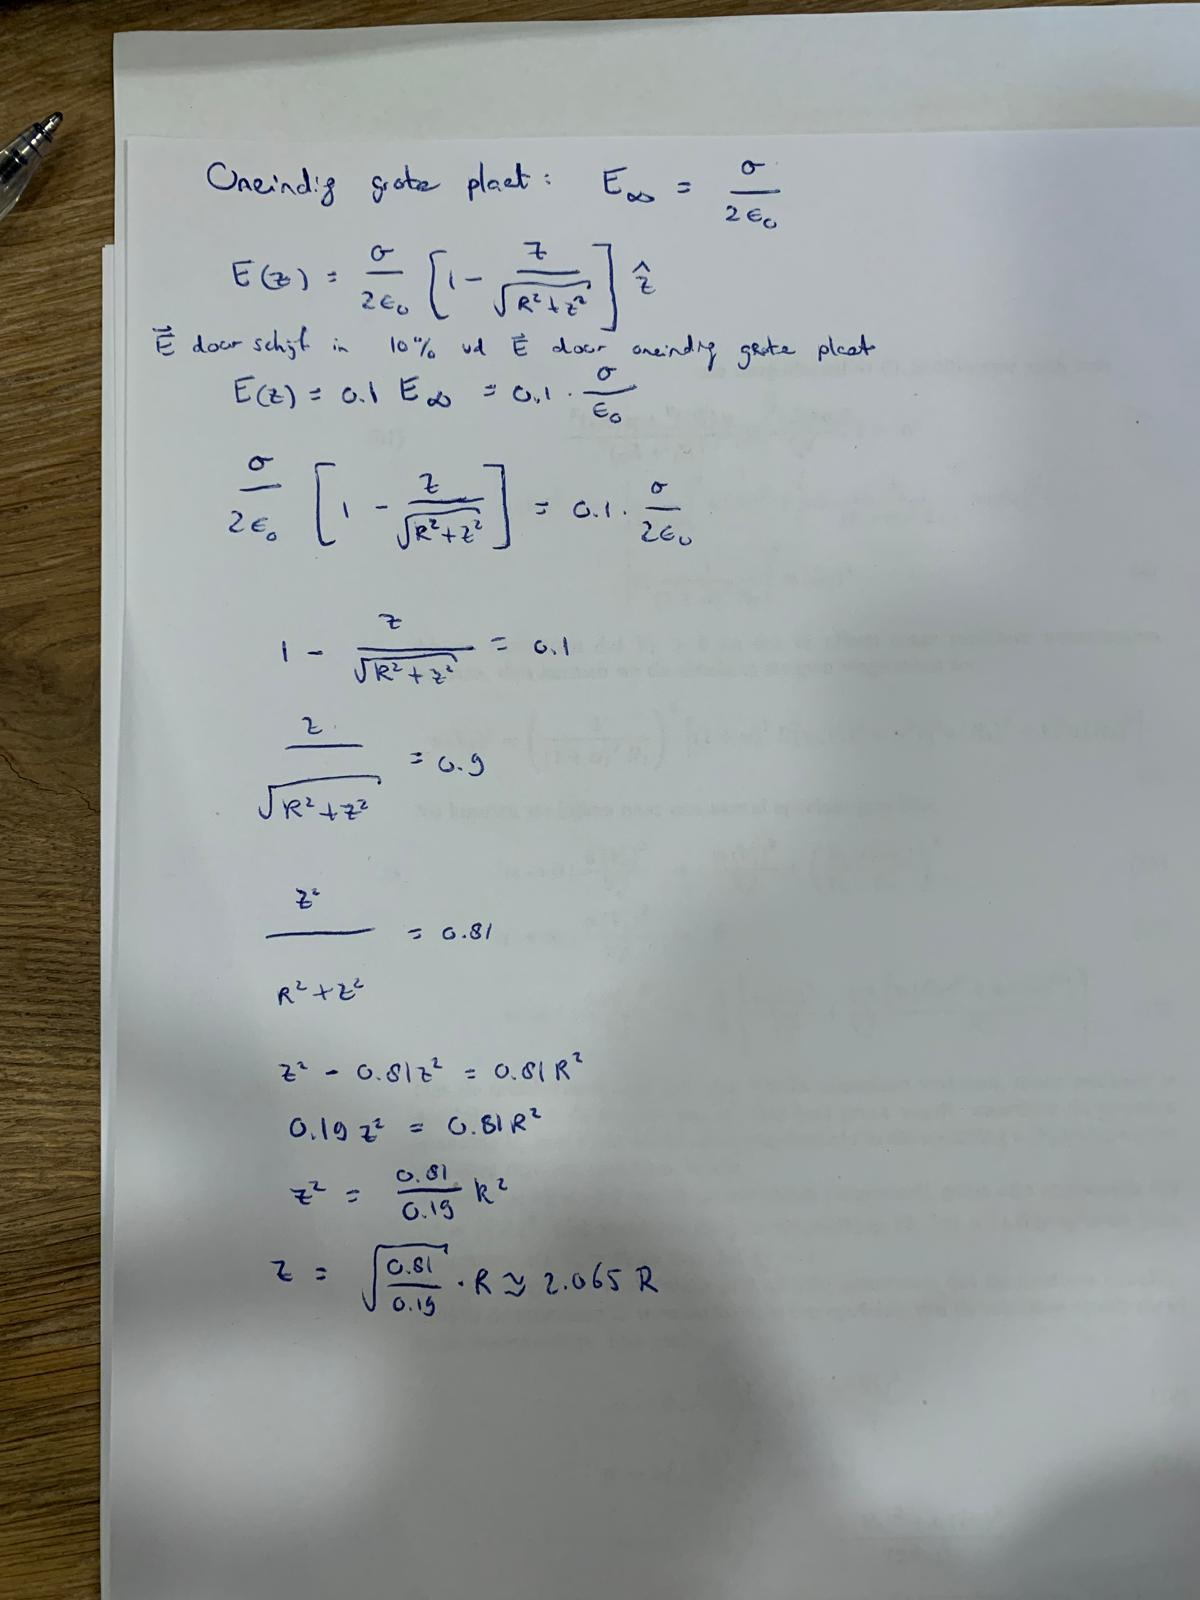

### 3) Een geladen schijf op een constant potentiaal

We zullen nu het verschil bestuderen tussen een uniform geladen schijf en een geleidende schijf die op een bepaald potentiaal gehouden wordt.
De code hieronder lost numeriek de laplace vergelijking op voor een geleidende schijf op een constant potentiaal. Hieruit volgt het potentiaal in de ruimte.

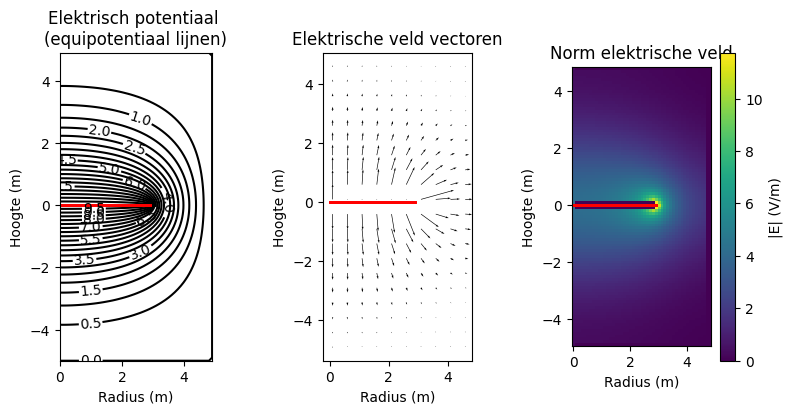

In [12]:
# Run deze cel pas deze niet aan.
V0 = 0  # electric potential at boundary of domain (V)

# Één schijf
z_pos_disk1 = 0  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = z_pos_disk1  # z-coördinaat van de tweede geleidende schijf (m) # in principe betekent dit gewoon 1 schijf
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V1)
# dit geeft aan dat V1=V2
"""--------------------------------------------------------------------
Veldberekening voor een geleidende schijf
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V1, 1e-3)
Er, Ez, normE = compute_E_disk(V,B,grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)

#### Vraag 3a: De simulatie van het elektrische veld van een geleidende schijf op constant potentiaal

1. Plot de elektrische veld sterkte op de as van de schijf.
2. Print de norm van het elektrische veld op de as heel dicht bij het midden van de schijf, zorg hier voor een nette opmaak.

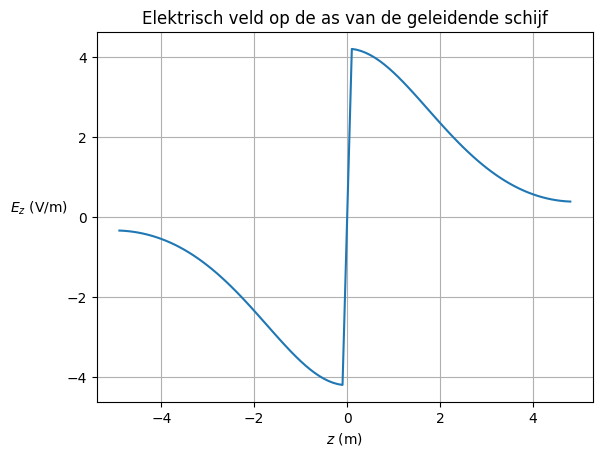

Norm van het elektrische veld vlak bij het midden van de geleidende schijf (z ≈ -0.000 m): 1.521e-05 V/m


In [13]:
###
###Jouw code hier###
# Elektrisch veldsterkte op as van de schijf betekent de z-component van E op r=0.
idx_r0 = find_idx_nearest(0, r_for_E) 
# Elektrisch veld op de as van de schijf
Ez_axis = Ez[:, idx_r0]
# Plot
plt.figure()
plt.plot(z_for_E, Ez_axis)
plt.xlabel("$z$ (m)")
plt.ylabel("$E_{z}$ (V/m)", rotation=0, labelpad=20)
plt.title("Elektrisch veld op de as van de geleidende schijf")
plt.grid()
plt.show()
# Vind index van z dicht bij het midden van de schijf
idx_z_center = find_idx_nearest(z_pos_disk1, z_for_E)
# Norm van E vlakbij het midden van de schijf
E_center = normE[idx_z_center, idx_r0]
print(f"Norm van het elektrische veld vlak bij het midden van de geleidende schijf (z ≈ {z_for_E[idx_z_center]:.3f} m): {E_center:.3e} V/m")
###

#### Vraag 3b: De oppervlakte lading in het midden van een geleidende schijf op constant potentiaal

1. Met welke formule kan je de oppervlaktelading benaderen in het midden van de schijf($r=0$, $z=0$)?
2. Print netjes de benadering van de oppervlakte lading in het midden van de schijf.

##### Antwoord 3b

Volgens de wet van Gauss: Q(enc)/epsilon0 = sigma* A / epsilon0. Stel je hebt een cilinder half boven de schijf en half in de geleidende schijf, dan is: flux = E(loodrecht) * A. Dus de kringintegraal van E * dA = E(loodrecht) * A. E(loodrecht) = sigma/epsilon0. sigma_center(r->0,z->0)= E(loodrecht)*epsilon0

In [14]:
#### Print met deze cel met een nette opmaak je antwoord op vraag 3b 2.
# Voor een dunne cirkelvormige schijf op potentiaal V0:
# sigma(r) = 2 * epsilon_0 * V0 / (pi * sqrt(a^2 - r^2))
# sigma_center = 2 * epsilon0 * V0 / (np.pi * disk_radius)
# print(f"σ_midden ≈ {sigma_center:.3f} C/m²")

sigma_center1 = E_center * epsilon0
print(f'sigma center is: {sigma_center1:.3f} C/m²')

sigma center is: 0.000 C/m²


#### Vraag 3c: De oppervlaktelading van een geleidende schijf op constant potentiaal

De oppervlakte lading $\sigma(r)$ van een geleidende schijf met straal $R$ is niet uniform verdeeld over de schijf, maar wordt gegeven door (Problems 2.58 and 2.63 Griffiths 5th edition):
$$\sigma(r) = \frac{Q}{2 \pi R \sqrt{R^2 - r^2}}$$

1. Bereken de totale lading op de schijf met behulp van vraag 3a en 3b.
2. Vergelijk de oppervlakte lading in het centrum van de geleidende schijf met dat van een uniform geladen schijf met dezelfde totale lading.
3. Plot de oppervlakte lading van de geleidende schijf met de berekende lading $Q$, tussen $r = 0$ en $R$.
4. Plot in hetzelfde figuur de oppervlaktelading van een uniform geladen schijf met dezelfde lading $Q$.


Totale lading: 0.000 C
1.091141187046743e-14


C:\Users\Eline\AppData\Local\Temp\ipykernel_16840\4063550655.py:15: RuntimeWarning: divide by zero encountered in divide
  sigma_nonuniform = Q_tot / (2 * np.pi * disk_radius * np.sqrt(disk_radius**2 - r**2))


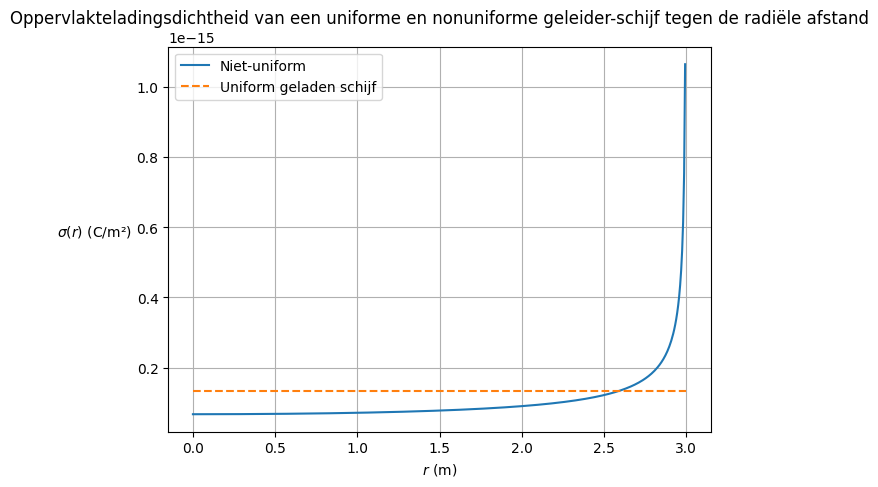

In [15]:
###
###Jouw code hier###
# Q(tot)= integraal van R tot 0 van sigma(r) dA
# dA = 2pi* r in poolcoord.
# Uit integratie volgt dat Q(tot)=Q
# 1.
# Totale lading Q (gebaseerd op middenladingsdichtheid benadering)
Q_tot = sigma_center1 * np.pi * disk_radius**2 
print(f"Totale lading: {Q_tot:.3f} C")
# 2, 3, 4
# radial vector
r = np.linspace(0, disk_radius, 500)

# Niet-uniforme schijf (Griffiths)
sigma_nonuniform = Q_tot / (2 * np.pi * disk_radius * np.sqrt(disk_radius**2 - r**2))
# Uniform geladen schijf. Hierbij is de ladingsdichtheid onafhankelijk van r. 
# sigma uniform = Qtot/ A = Qtot/ pi * R^2 
sigma_uniform = Q_tot / (np.pi * disk_radius**2) * np.ones_like(r)
print(Q_tot / np.pi * disk_radius**2)
# Plot
plt.figure(figsize=(7,5))
plt.plot(r, sigma_nonuniform, label='Niet-uniform')
plt.plot(r, sigma_uniform, '--', label='Uniform geladen schijf')
plt.xlabel('$r$ (m)')
plt.ylabel('$σ (r)$ (C/m²)', rotation=0, labelpad=30)
plt.title('Oppervlakteladingsdichtheid van een uniforme en nonuniforme geleider-schijf tegen de radiële afstand')
plt.legend()
plt.grid(True)
plt.show()
# er is idd te zien dat bij r=0 -> sigma(nonuniform) = Q/ 2* pi * R ^2 = 0.5 * sigma(uniform)
###

#### Vraag 3d: Het edge effect

1. Bepaal het maximum elektrische veld door de geleidende schijf in de simulatie.
2. Bepaal waar in de ruimte dit maximum zich bevindt.
3. Hoeveel hoger is dit maximum dan het elektrische veld in het midden van de schijf?
4. Print met een nette opmaak de waardes die je hier hebt berekend.
5. Leg uit wat de oorzaak van dit lokaal hoge elektrische veld is?


In [16]:
# Deze cel kan je gebruiken om van vraag 3c 1 tot en met 4 te beantwoorden.\
# 1.
# maximum E-veld door geleidende schijf
# Het edge-effect betekent dat het maximale E-veld aan de rand van de schijf zit.
# Dus bij r->R en z->0.
idx_rR = find_idx_nearest(disk_radius, r_for_E) 
# de functie voor z->0 was al eerder gedefinieerd met idx_z_0
# Deze indices implementeren in matrix normE
max_E_veld = normE[idx_z_zero, idx_rR]
print(f"Maximale E-veld: {max_E_veld:.3f} V/m")
# 2.
print(f"Het indexnummer van de maximale grootte van het E-veld:({idx_z_zero:.0f}, {idx_rR:.0f})")
# Dit punt bevindt zich dus net boven de rand van de schijf.
# Nota bene. dit geeft hetzelfde resultaat:
print(f"{np.max(normE):.3f} V/m")
# 3,4.
# Norm van E vlakbij het midden van de schijf
E_center = normE[idx_z_center, idx_r0]
print(f"Norm van het elektrische veld vlak bij het midden van de geleidende schijf (z ≈ {z_for_E[idx_z_center]:.3f} m): {E_center:.3e} V/m")
# vermenigvuldigingsfactor.
multiplier = max_E_veld/ E_center
print(f"multiplier:{multiplier:.3f}")
# difference
difference = max_E_veld -  E_center

Maximale E-veld: 11.753 V/m
Het indexnummer van de maximale grootte van het E-veld:(50, 29)
11.753 V/m
Norm van het elektrische veld vlak bij het midden van de geleidende schijf (z ≈ -0.000 m): 1.521e-05 V/m
multiplier:772488.589


##### Antwoord 3d.5

Binnenin de geleider is E-veld= 0. Het oppervlak is een equipotentiaal. Het veld net buiten het oppervlak moet loodrecht staan op de geleider. Omdat er bij de rand een kromming is in de z-richting, is spreiden de veldlijnen zich sterker uit (E(loodrecht) wordt groter bij de rand ). Hierdoor ontstaat minder afstoting van de ladingen onderling, en dus kruipen meer ladingen naar de rand. Als gevolg hiervan wordt de ladingsdichtheid groter. E(loodrecht)= sigma/ epsilon0. Als E(loodrecht) groter wordt, moet sigma ook groter worden. 
Voor een dunne nonuniforme schijf (=geleidende schijf) is: sigma_nonuniform = Q_tot / (2 * np.pi * disk_radius * np.sqrt(disk_radius^2 - r^2)). Als r->disk_radius, gaat sigma_nonuniform naar oneindig. Als dit gebeurt, moet E(loodrecht) ook naar oneindig gaan.


### 4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$

In de cel hieronder wordt weer op dezelfde manier als in opdracht 3 de laplace vergelijking van deze situatie opgelost.

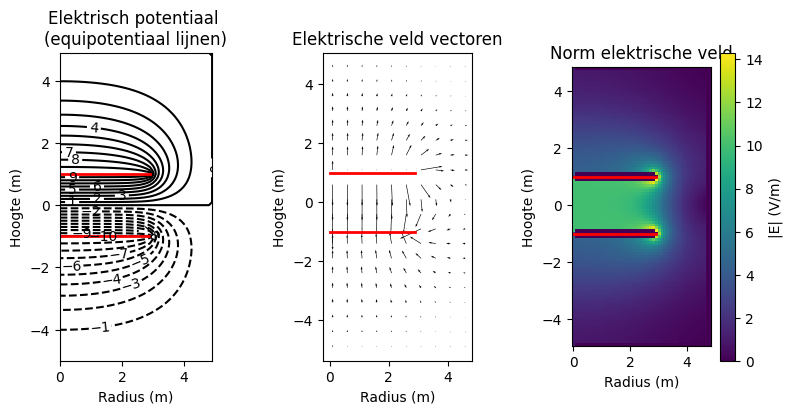

In [17]:
# Run deze cel en pas de cel aan in vraag 4f.
# Voor twee schijven
spacing_between_disks = 2  # (m)
z_pos_disk1 = spacing_between_disks/2  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = -spacing_between_disks/2  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)
V2 = -10  # elektrische potentiaal van de tweede geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V2)

"""--------------------------------------------------------------------
Veldberekening voor de twee geleidende schijven
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V2, 1e-3)
Er, Ez, normE = compute_E_disk(V, B, grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)


#### Vraag 4a: Het $z$-component van het numeriek berekende elektrische veld van twee geleidende platen

1. Plot het $z$-component van het numeriek berekende elektrische veld op de as van de schijven.


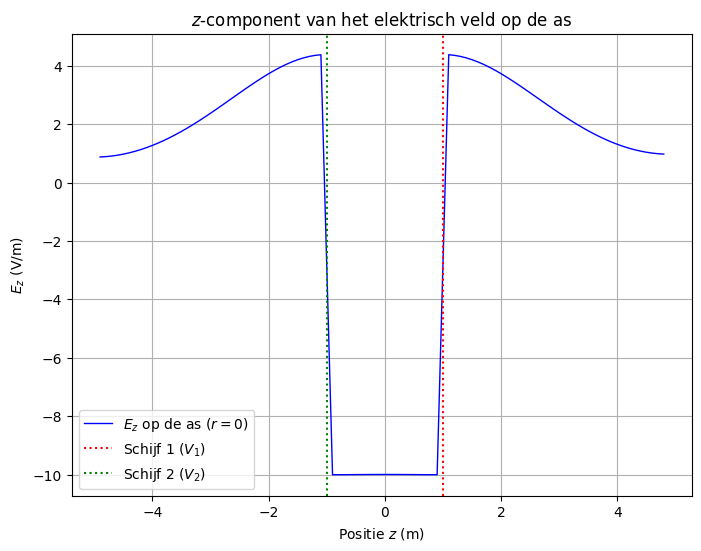

In [18]:
###
###your code here###
Ez_axis = Ez[:, idx_r0]
# plotten
plt.figure(figsize=(8, 6))
plt.plot(z_for_E, Ez_axis, label='$E_z$ op de as ($r=0$)', color='blue', linewidth=1)
plt.title('$z$-component van het elektrisch veld op de as')
plt.xlabel('Positie $z$ (m)')
plt.ylabel('$E_z$ (V/m)')
plt.grid()
plt.axvline(x=z_pos_disk1, color='red', linestyle=':', label='Schijf 1 ($V_1$)')
plt.axvline(x=z_pos_disk2, color='green', linestyle=':', label='Schijf 2 ($V_2$)')
plt.legend()
plt.show()  
###

#### Vraag 4b: Verschillen tussen verschillende configuraties

1. Gegeven het potentiaal tussen twee geleidende platen, wat is het theoretische elektrische veld in elke regio? Laat dit zien met een afleiding en een schets die de verschillende regio's aangeeft.
2. Beschrijf het numeriek berekende elektrische veld op de as van de schijven, komt dit overeen met het theoretische elektrische veld?
3. Vergelijk het numeriek berekende elektrische veld tussen de twee schijven ($r=0$ and $z=0$) met dat van een enkele geleidende schijf op hetzelfde potentiaal(vraag 3a), welk voordeel heeft deze configuratie?

##### Antwoorden 4b

Voor theoretisch oneindig lange platen, geldt dat de laPlace-vergelijking alleen afhangt van z.

#### Vraag 4c: De capaciteit tussen twee geleidende platen

1. Bepaal de verwachte oppervlakte lading op de binnenzijde van een van de schijven.
2. Bepaal de verwachte totale lading op beide schijven.
3. Bepaal de capaciteit van deze situatie.
4. Print alle bepaalde waardes op een nette en overzichtelijke manier.

In [19]:
###
###your code here###
###

#### Vraag 4d: Theoretische oppervlakte lading

1. Is de oppervlaktelading aan de buitenkant van de schijven gelijk aan nul, beargumenteer waarom wel of niet.
2. Wat is het elektrische veld nabij het oppervlak van een geleider?

##### Antwoorden 4d

*Beantwoord in deze markdown cel vraag 4d.*

#### Vraag 4e: Numeriek berekende ladingsdichtheid

1. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net onder de onderste schijf.
2. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de onderkant van de onderste geleidende plaat.
3. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net boven de onderste schijf.
4. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de bovenkant van de onderste geleidende plaat.
5. Print de bepaalde waardes op een nette en overzichtelijke manier.

In [20]:
###
###Your code here###
###

#### Vraag 4f: Conclusies over de ladingsdichtheid op de twee schijven

1. Wat kan je uit vraag 4d en e concluderen over de daadwerkelijke lading op een schijf in tegenstelling tot de berekende lading in vraag 4c?
2. Wat is de invloed hiervan op de capaciteit berekend in vraag 4c?
3. Run de cel net onder het kopje vraag 4 opnieuw, maar dan met een kleinere afstand tussen de schijven, wat verandert er?

##### Antwoorden 4f

*Beantwoord vraag 4f in deze cel.*

### 5) Voorbereidende opdracht voor de fysieke DEF ontwerpopdracht

In deze vraag zullen we ingaan op benodigde voorkennis voor de fysieke ontwerpopdracht "Maak een sensor met condensatoren". De formules die je in deze opdracht opstelt, heb je nodig gedurende de fysieke ontwerpopdracht.

In deze vraag zullen we kijken naar de ideale vlakke plaat condensator. Als de afstand tussen de platen veel kleiner is dan de grootte van de platen dan wordt de aanname gemaakt dat het veld tussen de platen constant is. Deze aanname zal niet helemaal overeenkomen met de werkelijkheid, zoals je in deze opdracht en de fysieke DEF ontwerpopdracht achter zal komen.

#### Vraag 5a: Functies voor de capaciteit van enkele opdrachten

1. Vind de formule voor de capaciteit van een vlakke plaat condensator en een cilinder condensator, onder de aanname dat de afstand tussen de platen veel kleiner is dan het oppervlakte van de condensator (vlakke plaat aanname).
2. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een vlakke plaat condensator als output heeft.
3. Vind de formule voor de capaciteit van een cilinder condensator onder de aanname dat de afstand tussen de binnen en buiten wand klein is.
4. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een cilinder condensator als output heeft.

In [21]:
#1,2,3,4.
def vlakkeplaat(epsilon, D, breedte, L=None, C=None):
    # Als L gegeven is → bereken C
    if L is not None and C is None:
        A = breedte * L
        C = epsilon * A / D
        return C

    # Als C gegeven is → bereken L
    elif C is not None and L is None:
        L = (C * D) / (epsilon * breedte)
        return L
    else:
        raise ValueError("Geef ofwel L ofwel C op, maar niet beide.")
# voor een cilinder is het gaussisch oppervlak: een cilinder.
# E* dA = Q(enc)/epsilon
# E* 2* pi * R*l = Q(enc)/epsilon
# -dV = E *dr
# V = Q/(2* pi * epsilon* L) * ln(b/a)
# b= straal buitenste cilinder
# a= straal binnnenste cilinder
# C = Q/V
# C =(2* pi * epsilon* L)/ln(b/a)
# dit reduceert tot de formule van vlakke plaat als b-a=d (afstand tussen cilinders) <<a.
# want: ln(b/a) = ln(a+d/a)= ln(1+d/a)
# voor d/a <<1: ln(1+d/a) = d/a
# C = (2* pi * epsilon* L* a)/d = epsilon * A/d
def cilinder(epsilon, b,a, L=None, C=None):     # hiermee verplicht je dat ofwel C ofwel L gegeven moet zijn, maar ze hoeven niet allebei gegeven te zijn.
    if b <= a:
        raise ValueError("De buitenstraal b moet groter zijn dan de binnenstraal a.")

    d= b-a
    # Als L gegeven is wordt C berekend
    # Controleer of we de vlakke-plaatbenadering mogen gebruiken
    if L is not None and C is None:
        if d / a <= 0.05:     #gekozen klein getal
            A = 2 * np.pi * a * L  # manteloppervlak van de binnenste cilinder
            C = epsilon * A / d
            print("Vlakke-plaatbenadering gebruikt omdat d << a")
        else:
            C = (2 * np.pi * epsilon * L) / np.log(b / a)
        return  C
    # Als C gegeven is wordt L berekend
    elif C is not None and L is None:
        if d / a <= 0.05:
            L = (C * d) / (2 * np.pi * epsilon * a)
        else:
            L = (C * np.log(b / a)) / (2 * np.pi * epsilon)
        return L
    
    else:
        raise ValueError("Geef ofwel L ofwel C op, maar niet beide.")

#### Vraag 5b: Capaciteit van enkele simpele condensatoren

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder staan een aantal condensatoren waarvoor jullie de capaciteit gaan berekenen. Print de capaciteit van elke condensator op een nette en overzichtelijke manier.
1. Bereken de capaciteit van een condensator gemaakt van twee vierkante plaatjes van 10 bij 10 cm met een plaatafstand van 1 mm en lucht als medium?
2. Bereken de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm met een lengte van 10 cm en lucht als medium?
3. Bereken de capaciteit van de condensatoren als de afstand tussen de platen verdubbeld
4. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven beschreven als ze gevuld zijn met water.
5. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven als de holte gevuld is met PVC.


In [22]:
###your code here###
#1.
epsilon_0 = 8.854e-12  # F/m    # permittiviteit van vacuum
epsilon_r_lucht = 1           # lucht
epsilon_r_water = 80    # water bij 293-298 K
A = 0.1 * 0.1           # m²
D = 0.001               # m

# Bereken capaciteit
C1 = vlakkeplaat(epsilon_0, epsilon_r_lucht, A, D)
print(f"1. Capaciteit van de vlakke-plaatcondensator: {C1:.1e} F")
#2.
a = 0.0045
b = 0.005
L = 0.1

C2 = cilinder(epsilon_0 * epsilon_r_lucht, b, a, L=L)
print(f"2. Capaciteit van de cilindercondensator: {C2:.1e} F")
#3a.
# Bereken capaciteit
C3a = vlakkeplaat(epsilon_0, epsilon_r_lucht, A, 2*D)
print(f"3a. Capaciteit van de vlakke-plaatcondensator met verdubbelde d: {C3a:.1e} F")
#3b
# buitenstraal vergroten zodat afstand: b-a verdubbelt
b_nieuw = a + 2*(b - a)
C3b = cilinder(epsilon_0 * epsilon_r_lucht, b_nieuw, a, L=L)
print(f"3b. Cilinder (afstand verdubbeld): {C3b:.3e} F")
#4a.
C_4a = vlakkeplaat(epsilon_0, epsilon_r_water, A, D)
C_4b = cilinder(epsilon_0 * epsilon_r_water, b, a, L=L)
print(f"4a. Capaciteit van de vlakke-plaatcondensator met water: {C_4a:.1e} F")
print(f"4b. Capaciteit van de cilindercondensator met water: {C_4b:.1e} F")

#5.
epsilon_r_pvc = 3 #bij bij 293-298 K
C_5a = vlakkeplaat(epsilon_0, epsilon_r_pvc, A, D)
C_5b = cilinder(epsilon_0 * epsilon_r_pvc, b, a, L=L)
print(f"5a. Capaciteit van de vlakke-plaatcondensator met PVC: {C_5a:.1e} F")
print(f"5b. Capaciteit van de cilindercondensator met PVC: {C_5b:.1e} F")
###

1. Capaciteit van de vlakke-plaatcondensator: 8.9e-17 F
2. Capaciteit van de cilindercondensator: 5.3e-11 F
3a. Capaciteit van de vlakke-plaatcondensator met verdubbelde d: 1.8e-16 F
3b. Cilinder (afstand verdubbeld): 2.772e-11 F
4a. Capaciteit van de vlakke-plaatcondensator met water: 1.1e-18 F
4b. Capaciteit van de cilindercondensator met water: 4.2e-09 F
5a. Capaciteit van de vlakke-plaatcondensator met PVC: 3.0e-17 F
5b. Capaciteit van de cilindercondensator met PVC: 1.6e-10 F


#### Vraag 5c: Condensatoren uit het dagelijkse leven

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder is een foto te zien van condensatoren die in het dagelijkse leven gebruikt wordt.
Print de capaciteiten in deze vraag op een nette en overzichtelijke manier.
1. In figuur 5.1 is een condensator te zien van 1 $\mu F$, stel deze condensator kan geapproximeerd worden als een cilinder condensator met binnendiameter 5 mm en een buitendiameter van 6 mm. Bereken wat de lengte van de condensator dan zou zijn.
Stel dat we een vierkante plaat condensator hebben van 1 $\mu F$.
2. Bereken hoe lang de vlakke plaat condensator moet zijn als er 0.5 mm tussen de platen zit en de platen 6 mm breed zijn.

![figure 5.1](figures/Condensator_1_uF.jpg)

##### Figure: 5.1 Een 1 microfarad condensator.

In [23]:
#5c1.
# #Cylindergegevens
r_binnen = 5e-3 /2 #m
r_buiten = 6e-3 /2 #m
C = 1e-6 #F
d = r_buiten - r_binnen

# functie uit 5a gebruiken
L_5c_1 = cilinder(epsilon0 * epsilon_r_lucht, r_buiten, r_binnen, C=C)
print(f"Vereiste lengte van de cilinder condensator: {L_5c_1:.1f} m")
#5c2.
#Plaatgegevens
b = 6e-3 #m
d = 0.5e-3 #m
C = 1e-6 #F

L_5c_2 = vlakkeplaat(epsilon0 * epsilon_r_lucht, D, b, C=C)
print(f"Vereiste lengte van de vlakke platen:        {L_5c_2:.1f} m")

Vereiste lengte van de cilinder condensator: 3277.3 m
Vereiste lengte van de vlakke platen:        18823.9 m


#### Vraag 5d: Hoge capaciteit condensatoren

1. Beargumenteer of je antwoorden uit vraag 5c realistisch zijn.
2. Bekijk je formule uit vraag 5a en bedenk hoe ze dit binnen in de condensator opgelost hebben.

##### Antwoorden 5d

Nee, cilinder- en plaatcondensatoren zijn in de realiteit niet kilometers lang. Om C groter te maken bij relatief kleine lengtes van de condensator, moet epsilon groter worden. Waarschijnlijk worden in de condensatoren tussen de twee platen bepaalde onbekende stoffen gebruikt, die dan een hogere $\epsilon_r$-waarde hebben dan lucht.

#### Vraag 5e: Condensator in een achtbaan

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

Met het vak inleidend practicum zijn jullie naar Drievliet gegaan om daar metingen aan de attracties te doen. In Drievliet staat de achtbaan Formule X, deze achtbaan heeft een topsnelheid van 70 $\frac{\text{km}}{\text{h}}$ en bevat een treintje met plek voor 6 mensen. Deze snelheid bereikt de achtbaan door heel snel een karretje weg te schieten, dit wordt gedaan door de treintjes met een lineaire inductie motor te versnellen. Om de impact hiervan op het stroomnet te beperken gebruiken zij een condensator om de energie op te slaan en dan in een keer af te staan aan het treintje. In deze opdracht gaan we kijken wat de afmetingen zouden moeten zijn als ze vlakke plaat condensatoren zouden gebruiken.

De energie die opgeslagen is in een condensator kan berekend worden met de onderstaande formule.

$E = \frac{1}{2} CV^2$
Hierin is $E$ de totaal opgeslagen energie $C$ de capaciteit en $V$ het voltage waarop de condensator opereert, in dit geval $10$ $kV$.
1. Schat de massa van een treintje dat afgeschoten wordt.
2. Bereken de totale energie van het treintje na het afschieten.
3. Bereken de totale capaciteit van de condensator.
4. Bereken het oppervlakte van een vlakke plaat condensator die deze capaciteit heeft als die gevuld is met water en de platen 1 mm van elkaar afstaan.
5. Print alle berekende waardes op een nette en overzichtelijke manier.
6. Is dit realistisch, bedenk een manier hoe dit toch kan in een relatief klein volume.


In [24]:
# 1.
# schatting trein van 500 kg. + 80kg * 6 personen = 480 kg. Tezamen = 1e3 kg.
m_treintje = 1.0e3 #kg
print(f"De massa van het treintje is: {m_treintje:.1e} kg")
# 2. totale energie
# gegevens
V_condensator = 1e4 #V
v_treintje_max = 70/3.6 #m/s
E_kin_max = (1/2) * m_treintje * v_treintje_max**2
print(f"De maximale kinetische energie van het treintje is: {E_kin_max:.2e} J")
# 3 totale capaciteit
C = (2 * E_kin_max)/(V_condensator**2)
print(f"De totale capaciteit van de condensator is: {C:.2e} F")
# 4 oppervlakte vlakke plaat
# aanname dat de vlakke plaat een vierkant is met opp: L**2
d = 1e-3 #m
epsilon = epsilon_0*epsilon_r_water
# L = vlakkeplaat(epsilon, d, L, C=C)
#print(L)
# dit werkt niet
# Voor vierkante platen: breedte = L
# L = sqrt(C * D / epsilon)
L_plaat = np.sqrt(C * D / epsilon)
A_plaat = L_plaat**2
print(f"Oppervlakte vlakke plaat: {A_plaat:.1e} m^2")

De massa van het treintje is: 1.0e+03 kg
De maximale kinetische energie van het treintje is: 1.89e+05 J
De totale capaciteit van de condensator is: 3.78e-03 F
Oppervlakte vlakke plaat: 5.3e+03 m^2


##### Antwoorden 5e

Nee, een condensatorplaat van een kilometer bij een kilometer is niet praktisch. Echter, als je dunne platen met kleine tussenafstand (d) oprolt tot een cilinder of opstapelt, kan je het in een relatief klein volume wringen en de capaciteit verhogen. Ook kan je epsilon_r vergroten (hoog-permittiviteit diëlektricum) om dezelfde capaciteit in een klein volume te realiseren.

#### Vraag 5f: Veranderende capaciteit

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

1. Bereken en plot de capaciteit van een vlakke plaat condensator van $10$ bij $10$ $cm$ waarbij de afstand tussen de platen lineair toeneemt van $0.5$ $mm$ tot $5$ $mm$.
2. Bereken en plot de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm en 10 cm lang, waarbij de binnencilinder er langzaam in 10 seconde uitgetrokken wordt.

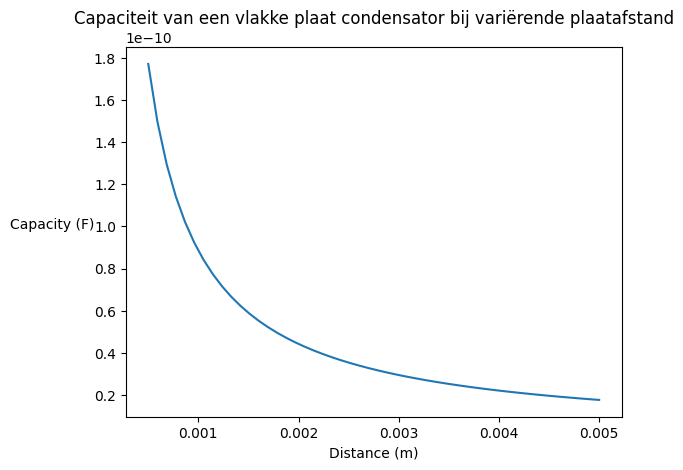

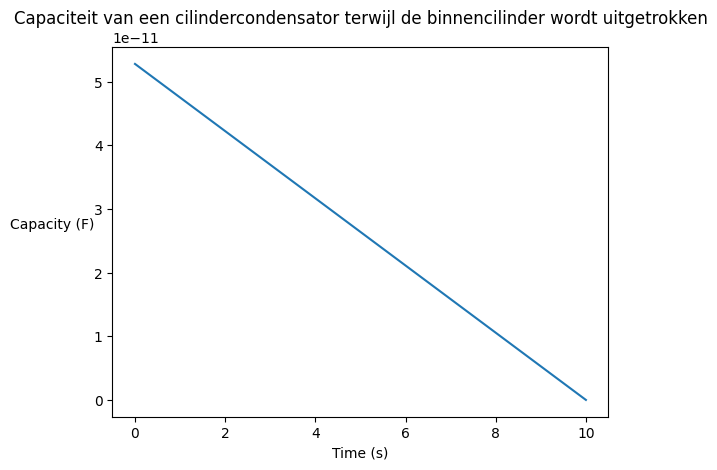

In [25]:
# 1.
#Vlakke plaat condensator
# variabele d
d = np.linspace(0.5e-3,5e-3,50)
VP_L = 0.10         # m
VP_b = 0.10         #m
VPcondensator = vlakkeplaat(epsilon0* epsilon_r_lucht, d, VP_b, L=VP_L)
# bereken oppervlak
A = 10e-2 * 10e-2 #m^2

plt.plot(d,VPcondensator)
plt.title("Capaciteit van een vlakke plaat condensator bij variërende plaatafstand")
plt.xlabel("Distance (m)")
plt.ylabel("Capacity (F)", rotation=0, labelpad=30)
plt.show()
#2.
#Cilinder Condensator
CIL_L = 0.10        # m
r_binnen,r_buiten = 9e-3, 10e-3 #m
# tijd
t = np.linspace(0,10,50)
# snelheid : 10 cm afleggen in 10 sec
v = -10e-2/10 #m/s
# lengte varieert
L = CIL_L + v*t
CILcondensator = cilinder(epsilon0* epsilon_r_lucht, r_buiten,r_binnen, L=L)

plt.plot(t,CILcondensator)
plt.title("Capaciteit van een cilindercondensator terwijl de binnencilinder wordt uitgetrokken")
plt.xlabel("Time (s)")
plt.ylabel("Capacity (F)", rotation=0, labelpad=30)
plt.show()

## Stop hier met werken tot na de fysieke ontwerpopdracht in week 3.

### 6) Reflectie opdracht voor na de fysieke ontwerpopdracht


Als het goed is, heeft ieder teamlid van deze simulatie-opdracht een andere opstelling ontworpen hebben tijdens de fysieke ontwerpopdracht. Kies in goed overleg voor deze opdracht een van jullie twee ontwerpen.

Voeg hieronder eerst een foto in van je opstelling die je gekozen hebt.

Jullie gaan in deze opdracht het verschil tussen jullie voorspelde verband en jullie uiteindelijke verkregen kalibratie grafiek proberen te verklaren. Er zijn hiervoor drie mogelijke paden die jullie kunnen kiezen om te onderzoeken, Kies deel a, b of c en werk die volledig uit voor jullie ontwerp. Let op je hoeft er maar een uit te werken.

Verander de tekst hieronder zodat deze naar jouw foto verwijst. Zorg dat de foto in de map figures staat!
![figure 5.1](figures/opstelling2_arduino.jpeg)

#### Vraag 6a: Dunne laag niet meegerekende diëlektricum
Deze vraag is goed om te kiezen als je in je ontwerp een kleine laag extra materiaal hebt en deze tijdens de ontwerpopdracht niet hebben meegenomen in je theoretisch kalibratie grafiek.

1. Maak een nieuwe schets van je opstelling waarbij je de dikte van het extra diëlektricum meeneemt.
2. Leid de analytische oplossing af van de capaciteit van de hierboven getekende situatie.
3. Programmeer de analytische oplossing in python.
4. Maak hierna een plot van het kalibratiegrafiek, oude en nieuwe analytische oplossing in een grafiek.
5. Beschrijf en verklaar de verschillen tussen de grafieken.


##### Antwoorden 6a

*Laat in deze cel je analytische oplossing met schets zien, dit mag met foto's of via LATEX.*

In [26]:
# Schrijf hier de code voor je oplossing. Gebruik hier je eerder gemaakte functies
# def condensator_extra_laag(#jouw variabelen): # Schrijf hier jouw functie
    ## je functie


### Maak hier je plot

##### Antwoorden 6a

*Beschrijf en verklaar je verschillen in deze markdown cel.*

#### Vraag 6b1: Lading op een condensator met het edge effect meegenomen

In deze opdracht gaan we verder in op het Edge effect en de invloed daarvan op de praktische capaciteit. Deze opdracht bouwt voort op de vraag 4.3.
Jullie hebben tijdens de ontwerpopdracht vierkante platen gebruikt in tegenstelling tot de ronde platen waarvoor de factoren in figure[label] zijn afgeleid. Er is onderzoek gedaan naar de factoren waarmee de praktische capaciteit vergeleken met de daadwerkelijke capaciteit verschilt dat onderzoek vind je hier: https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=311759. Zoek in het onderzoek tabel 1 en formules 22 en 36 op.

1. Vergelijk de factor waarmee de schijf(disk) condensator verschilt met die van de vierkante plaat, kunnen we de vierkante plaat factor benaderen met de factor voor een disk condensator? Vergelijk het procentuele verschil tussen de factoren van de circulaire en vierkante platen, met de onzekerheden die in de meting zitten.



##### Antwoord 6b1

22: $b = \dfrac{d}{w} = \dfrac{plate seperation}{plate width} = aspect ratio$ <br>
36: $C_{DN} = \dfrac{C_D}{C_{D0}}$ <br>
De factor voor de disk-plaatcapaciteit is steeds iets hoger dan voor de vierkante plaatcapaciteit bij dezelfde geometrische verhouding (b). Bij de meeste praktische ontwerpen (waar de platen relatief dun zijn) is het verschil verwaarloosbaar klein ($< 2\%$). Dit verschil is verwaarloosbaar t.o.v. de praktische meetonzekerheden van de variabele C(DN) en C(square).
Bijvoorbeeld bij b=0.1 : b=d/w = 0.1.
(C(DN) - C(square))/ C(square) * 100% = (1.31809 - 1.29980) / 1.29980 × 100% ≈ 1.4%
Bij b=10, is het procentuele verschil echter 10 %. Maar omdat praktische onzekerheden van dikke platen in dezelfde orde van grootte zijn of misschien wel groter, blijft het gebruik van de schijf-factor een verdedigbare benadering. 

#### Vraag 6b2: Capaciteit van een condensator met het edge effect meegenomen

Vanaf hier nemen we aan dat factor van de circulaire platen ongeveer gelijk is aan de factor voor vierkante platen. De factor die de capaciteit van de vlakke plaat approximatie linkt aan de werkelijke capaciteit noemen we vanaf nu de idealiteitsfactor.

1. Bereken de daadwerkelijke theoretische capaciteit van de condensator uit de sanity check 3 van de fysieke ontwerpopdracht en print deze op een nette manier.
2. Vergelijk dit met de daadwerkelijke theoretische capaciteit met de capaciteit die je op de dag zelf hebt gemeten.

Vanaf hier gaan we verder met jullie sensor van de ontwerpopdracht "Maak een sensor met condensatoren":

3. Reken je theoretische kalibratie grafiek om met de idealiteitsfactor.
4. Vergelijk je nieuwe theoretische kalibratiegrafiek van je praktische kalibratiegrafiek van de dag zelf.

In [27]:
# Schrijf hier jouw code die de vlakke plaat capaciteit omschrijft naar de werkelijke capaciteit

# def C_niet_ideaal(#relevante parameters):
    # Jouw berekeningen


##### Antwoorden 6b2

*Doe in deze markdown cel je vergelijkingen voor de sanity check condensator en je kalibratiegrafiek.*

#### Vraag 6c: Niet linear diëlektricum optie 1

Niet alle materialen zijn een lineair diëlektricum. Een aantal van de materialen die sterk niet lineair gedrag vertonen zijn: sponzen, foam & rubber. Als je in je opdracht een materiaal gebruikt heb waarvan je verwacht dat het verband sterk niet lineair is kan dit een hele goede opdracht zijn.
| Materiaal |$\chi_2$   |
| :-------------|:-------------|
| Spons|  |

Als jouw materiaal hier niet tussen staat dan kan je zelf op zoek naar een waarde van $\chi_2$ in de literatuur.

#### Vraag 6c1

1. Leidt het D veld van de condensator af uit de wet van Gauss.
2. Vindt een analytische uitdrukking voor het elektrisch veld in termen van het D veld.

##### Antwoorden 6c 1

*Antwoord vraag 6c 1.*

#### Vraag 6c2

1. Programmeer je oplossingen voor het D en E veld in python, gebruik het D veld uit je fysieke ontwerpopdracht.

Als je het elektrische veld van een vierkante vlakke plaat condensator weet kan je de capaciteit berekenen met de onderstaande formule:
$C = \frac{A
E_z \epsilon_0}{\Delta V}$

2. Plot de capaciteit van het niet lineaire diëlektricum, het theoretische kalibratiegrafiek en de uiteindelijke kalibratiegrafiek van de fysieke ontwerpopdracht.
3. Verklaar verschillen tussen de grafieken.

In [28]:
 # Pas deze code aan zodat jouw opstelling doorgerekend wordt
def E_condensator(x1, x2, D):
    return None

#### Vraag 7

Hoeveel van de afwijking tussen je metingen en je oorspronkelijke voorspelde kalibratiegrafiek wordt verklaard door wat je bij vraag 6 hebt uitgerekend? Kan je een (aantal) elektrisch veld en capaciteit gerelateerde reden(en) verzinnen wat de rest van de afwijking tussen meting en voorspelde kalibratiegrafiek kan verklaren.

##### Antwoorden 7

*Antwoord vraag 7, de laatste.*